# AIM:
create evaluation workflow. Taking the manually extracted Ci impacts (validation set) and compare it with the CI impacts (llm_geolocations.ipynb) extrracted by the first LLM 1. 
As a first step the evaluation should be done only for the direct CI impacts - CI type, damage and geolocation

Issue:
* What is needed an approach that recognizes when an direct impact case is not detected by the model
Idea: 
* Split the original texts passed to the model on the exact chunks as again
* Then chunkwise check if the CI impacts from the validation set correspond in number and their textual similarity to the CI impacts infered by the LLM 1 and Entity Linking 

## Semantic Textual Similarity (STS)

Calculating the STS for both model configurations (chain of prompts, orchestration of models)
The outputs are cosine similarity scores for similar model outputs per chunk. They are ranked by score for each model, restricted to the top 20 results.  


In [221]:
import os
import sys
from pathlib import Path
import io
import gc
import time
import warnings
import subprocess
import importlib
import glob

from unidecode import unidecode
import langdetect
from fuzzywuzzy import fuzz
import torch
from huggingface_hub import login
import numpy as np
import spacy
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from matplotlib import pyplot as plt


sys.path.append('../')
from src.settings import settings as s
import src.document_cleaning as dc
import src.translation_model as tm
import src.utils as u
import src.datahandler as dh
import src.postprocess as pp
import src.visualization as v

# login to HF
# NOTE raises exception when env.variable does not exist (compared to os.envrion.get and its shortcut os.getenv)
os.getenv("HUGGINGFACE_TOKEN")

#  automatic linebreaks and multi-line cells.
pd.set_option("display.colheader_justify", "left")
pd.set_option('display.max_colwidth', 5000)


step = "step2"


### Direct CI impacts: LLM 1 vs domain-expertise 

In [ ]:
#  Suppress future warnings from PyTorch
warnings.filterwarnings("ignore", category=FutureWarning)


#  Define data dir where tags.csv and domain-expertise derived tag lists are found 
# VALID_DATA_FILENAME = s.VALID_DATA_FILENAME
VALID_DATA_FILENAME = "table_ci_impacts_sm_loc.csv"
PATH_VALID_DATA = s.PATH_VALID_DATA
PATH_EVAL_RESULT = s.PATH_EVAL_RESULT
# s.LLM_DATA_FILENAME = "llm1_NER_newWF.csv"
# s.LLM_DATA_FILENAME = "llm_1_updprompt_dNER.csv"
s.LLM_DATA_FILENAME = f"df_responses_{step}_ner_geollm.csv"
LLM_DATA_FILEPATH = Path(s.PATH_LLM_DATA / s.LLM_DATA_FILENAME)
SIMILARITY_LLM_FILENAME = s.SIMILARITY_LLM_FILENAME

df_valid_org = pd.read_csv(
    PATH_VALID_DATA / VALID_DATA_FILENAME,
    usecols=["publication_id", "ci1_type", "ci1_damage", "ci1_location", "sentence_reference"],
)
print(len(df_valid_org))
## pre-process: 
# remove undone entries
df_valid_org = df_valid_org[~df_valid_org.astype(str).apply(lambda x: x.str.contains("xx")).any(axis=1)]
# remove further location info (e.g. that entry is a town, Landkreis, Bavaria etc.)
# df_valid_org["ci1_location"] = df_valid_org["ci1_location"].replace(r"\s*\(.*\)", "", regex=True).str.strip()
df_valid_org = df_valid_org.dropna(subset=["publication_id"], how="all") # drop rows where citation info is missing
print(len(df_valid_org))
print(df_valid_org.publication_id.unique())

print(f"Collecting LLM responses from {step}")
# ## prediction data
# df_pred = pd.read_csv(
#     LLM_DATA_FILEPATH,
#    # usecols=["citation_id", "chunk_id", "infrastructure_type", "damage", "location", "chunk_text"]
# )
df_pred = pd.DataFrame()
for i, file in enumerate(glob.glob(os.path.join(s.PATH_DATA, "llm_outputs/responses_single_docs", f'*{step}*.csv'))):
    print(i, file)
    df_pred = pd.concat([df_pred, pd.read_csv(file)], ignore_index=True)



UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa3 in position 1080: invalid start byte

In [154]:
df_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   citation_id                391 non-null    object
 1   chunk_id                   391 non-null    object
 2   infrastructure_type        391 non-null    object
 3   infrastructure_group       0 non-null      object
 4   damage                     334 non-null    object
 5   location                   385 non-null    object
 6   ci_entity                  124 non-null    object
 7   geo_entity                 124 non-null    object
 8   coord_potential_locations  391 non-null    object
 9   chunk_text                 391 non-null    object
 10  infrastructure_type_org    290 non-null    object
 11  damage_org                 242 non-null    object
 12  locations_org              265 non-null    object
dtypes: object(13)
memory usage: 39.8+ KB


In [155]:
df_pred.head(1)

,citation_id,chunk_id,infrastructure_type,infrastructure_group,damage,location,ci_entity,geo_entity,coord_potential_locations,chunk_text,infrastructure_type_org,damage_org,locations_org
0,Skoulding 2023,1,airport,NaN,NaN,Rhodes,Major airport,Corfu,"{'Rhodes': ('36.1725297', '27.9194016', True), 'Corfu': ('39.6217347', '19.9180908', True), 'Sicily': ('37.4742763', '14.1385298', True), 'Curcuraci': ('38.2608690', '15.5679169', True), 'Italy': ('42.6384261', '12.6742970', True)}","The Messina area of Sicily has also seen wildﬁres breakout, with photos showing ﬂames engulﬁng part of the village of Curcuraci. Temperatures rose to 47.6C in some parts of the island on Monday, sparking at least 55 separate blazes. R E C O M M E N D E D Greece fires – live: Tourists in Rhodes and Corfu evacuated as Croatia also battles wildfires Major airport closed as wildfires now rage across Italy How long is the heatwave in Europe expected to last? 1/9 12/29/25, 9:46 PM Where are the ﬁres in Italy today as temperatures rise to 47.6C on Sicily? | The Independent How hot is it in Sicily? Italy – like much of southern Europe – has been hit by scorching temperatures bringing increased risk of ﬁres and deaths. Yesterday, temperatures rose to 47.6C in some parts of eastern Sicily, close to the record European high of 48.8C recorded on the island two years ago. The latest high temperatures has led the government to put 16 Italian cities on red alert. Where are the wildfires in Sicily?",airport,NaN,Corfu


In [156]:
df_pred["citation_id"].unique()

array(['Skoulding 2023', 'Brown 2010', 'Wilson 2024', 'Kettle 2020',
       'Artemis 2015', 'Wildhagen 2013', 'Karakatsani 2023', 'Kaur 2025',
       'AEMET 2024', 'Rozendaal 2021', 'EFE 2024', 'Khazai 2013',
       'AFP 2022', 'Fink 2004', 'Containerlift 2024', 'ABC 2024',
       "Lloyd's List 2024", 'Euronews 2024', 'Koks 2022',
       'Gilbody Dickerson 2024', 'European Investment Bank 2025'],
      dtype=object)

#### AS FUNC: Evaluate on same documents that were passed to LLM



In [157]:
print("Use only citations which are in both")


df_valid = df_valid_org[df_valid_org["publication_id"].isin(df_pred.citation_id.unique())]
# df_valid_org[df_valid_org["publication_id"].isin(citation_list)]
print("Valid citations:")
print(df_valid.publication_id.unique())

df_pred = df_pred[df_pred["citation_id"].isin(df_valid.publication_id.unique())]
print("Predicted citations:")
print(df_pred.citation_id.unique())

Use only citations which are in both
Valid citations:
['ABC 2024' 'Artemis 2015' 'Brown 2010' 'Containerlift 2024' 'EFE 2024'
 'Euronews 2024' 'European Investment Bank 2025' 'Gilbody Dickerson 2024'
 'Karakatsani 2023' 'Kaur 2025' 'Khazai 2013' 'Koks 2022' 'Rozendaal 2021'
 'Wildhagen 2013' 'Wilson 2024']
Predicted citations:
['Brown 2010' 'Wilson 2024' 'Artemis 2015' 'Wildhagen 2013'
 'Karakatsani 2023' 'Kaur 2025' 'Rozendaal 2021' 'EFE 2024' 'Khazai 2013'
 'Containerlift 2024' 'ABC 2024' 'Euronews 2024' 'Koks 2022'
 'Gilbody Dickerson 2024' 'European Investment Bank 2025']


In [158]:
print(df_valid.info())
print(df_pred.info())

<class 'pandas.core.frame.DataFrame'>
Index: 111 entries, 1 to 151
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   publication_id      111 non-null    object
 1   sentence_reference  111 non-null    object
 2   ci1_type            94 non-null     object
 3   ci1_damage          86 non-null     object
 4   ci1_location        88 non-null     object
dtypes: object(5)
memory usage: 5.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 289 entries, 7 to 390
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   citation_id                289 non-null    object
 1   chunk_id                   289 non-null    object
 2   infrastructure_type        289 non-null    object
 3   infrastructure_group       0 non-null      object
 4   damage                     241 non-null    object
 5   location                   283

In [159]:
# df_pred.loc[df_pred["citation_id"]== "Krausmann 2014"] # Krausmann -> large hallucinations when chunk-text is title or contact info (i.e when not about CI /impacts)

## MV to postprocess.fuc() drop dublicated predictions + upd (encod-utf-8)saving_llm_reuslts in loop (rm fix saving) + pp of NAN strings in LLm response


In [160]:

def convert_nan(series: pd.Series) -> pd.Series:
    """ convert representations of "NAN" to np.nan """
    # TODO use regex instead of ["NAN", "NaN", "nan"] by setting all possible representations of nan (e.g. "Nan") to lowercase 
    series = series.replace(["NAN", "NaN", "nan"], np.nan)

    return series


print(df_pred.info())
df_pred["infrastructure_type"] = convert_nan(df_pred["infrastructure_type"])
df_pred["damage"] = convert_nan(df_pred["damage"])
df_pred["location"] = convert_nan(df_pred["location"])

print(df_pred.info(), len(df_pred))

<class 'pandas.core.frame.DataFrame'>
Index: 289 entries, 7 to 390
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   citation_id                289 non-null    object
 1   chunk_id                   289 non-null    object
 2   infrastructure_type        289 non-null    object
 3   infrastructure_group       0 non-null      object
 4   damage                     241 non-null    object
 5   location                   283 non-null    object
 6   ci_entity                  99 non-null     object
 7   geo_entity                 99 non-null     object
 8   coord_potential_locations  289 non-null    object
 9   chunk_text                 289 non-null    object
 10  infrastructure_type_org    224 non-null    object
 11  damage_org                 181 non-null    object
 12  locations_org              199 non-null    object
dtypes: object(13)
memory usage: 31.6+ KB
None
<class 'pandas.core.frame.Da

In [161]:
print(len(df_pred))
unique_ci_geo_pairs = df_pred.drop_duplicates()
print("number of duplicates to remove:", len(df_pred) - len(unique_ci_geo_pairs))

df_pred = df_pred.drop_duplicates( )# .reset_index(drop=True, inplace=True)
print(len(df_pred))


289
number of duplicates to remove: 62
227


### remove records which are not about Europe 

In [162]:
df_pred = df_pred[~df_pred["location"].isin(["New York", "New Jersey"])]

### remove all records which are on country-level


In [163]:
# import geonamescache

# def get_countries():
#     geolocs_cache = geonamescache.GeonamesCache()
#     countries = geolocs_cache.get_countries()
#     ci_geo_countries = [*u.gen_dict_extract(countries, 'name')] 
#     # add further country names with abbrev. or "the" , incl. als regions which have the same name as their country (eg. Luxembourg- Provinz in Belgium)
#     ci_geo_countries = ci_geo_countries + ["the Netherlands", "Netherlands", "UK", "US", "U.S.", "USA"]
#     return ci_geo_countries


# # remove all records which are on country-level
# ci_geo_countries = get_countries()
# df_pred = df_pred[~df_pred["location"].isin(ci_geo_countries)]
# df_valid = df_valid[~df_valid["ci1_location"].isin(ci_geo_countries)]


In [ ]:
def split_text_into_multiple_rows(df: pd.DataFrame, column: str, split_at = " and ") -> pd.DataFrame:
    """ split text at splitting_point into multiple rows """
    # split CIs and LOCs with "and" into multiple rows
    df[column] = df[column].str.split(split_at)   
    # NOTE: Removes info from CI - drops info if CI is singular o plural (e.g, road and railway infrastrcutre --> "road", "railway infrastructure")
    df = df.explode(column=column)
    df = df.drop_duplicates().reset_index(drop=True)
    return df

# disentangle rows which contain multiple locations or CIs
df_pred = split_text_into_multiple_rows(df_pred, "location",  split_at = " and ")
df_pred = split_text_into_multiple_rows(df_pred, "location",  split_at = " or ")
df_pred = split_text_into_multiple_rows(df_pred, "infrastructure_type",  split_at = " and ").reset_index(drop=True)
df_valid = split_text_into_multiple_rows(df_valid, "ci1_location",  split_at = " and ")
df_valid = split_text_into_multiple_rows(df_valid, "ci1_location",  split_at = " or ")
df_valid = split_text_into_multiple_rows(df_valid, "ci1_type",  split_at = " and ").reset_index(drop=True) # make sure that same valid_sentences can occur multiple times, eg. in "Valencia and Sagunto port" (=2 rows)


/tmp/ipykernel_161876/940846034.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].str.split(split_at)


In [165]:

print(df_pred.location.unique())
print(df_valid.ci1_location.unique())

## TODO clean up loc --> MV this postprocessing to LLm extraction before passing to LLm Step2
# "( "  eg "Sinzig (in North Rhine-Westphalia)""
df_pred["location"] = df_pred["location"].str.split(r"\(", regex=True).str[0].str.strip()
df_valid["ci1_location"] = df_valid["ci1_location"].str.split(r"\(", regex=True).str[0].str.strip()
df_pred["location"] = df_pred["location"].str.split(", ").str[0].str.strip()  
df_valid["ci1_location"] = df_valid["ci1_location"].str.split(", ").str[0].str.strip()   
## handling loc with "railway tracks between "
df_pred["location"] = df_pred["location"].str.split("between").str[-1].str.strip()
df_valid["ci1_location"] = df_valid["ci1_location"].str.split("between").str[-1].str.strip()
## handling loc with "railway tracks in"  , set this after cleaning up "( " and ", " as it otherwise would take the later location
df_pred["location"] = df_pred["location"].str.split("in ").str[-1].str.strip()
df_valid["ci1_location"] = df_valid["ci1_location"].str.split("in ").str[-1].str.strip()
#  try to remove "the" already before passing to GeoLLM in extraction-WF
df_pred["location"] = df_pred["location"].replace(r"the ", " ", regex=False).str.strip()   
df_valid["ci1_location"] = df_valid["ci1_location"].replace(r"the ", " ", regex=False).str.strip()
## handling loc with "passing "
df_pred["location"] = df_pred["location"].replace(r"passing ", " ", regex=False).str.strip()   
df_valid["ci1_location"] = df_valid["ci1_location"].replace(r"passing ", " ", regex=False).str.strip()


print(df_pred.location.unique())
print(df_valid.ci1_location.unique())

['Britain' 'UK' 'Heathrow Airport' 'Spain' nan 'Saale' 'Rosenheim'
 'Raubling' 'Saxony-Anhalt' 'Bitterfeld' 'Belgian rail network'
 'Kop van Noord-Holland region' 'between Heerhugowaard' 'Den Helder'
 'between Bunnik' 'Veenendaal' 'between Utrecht' 'Ede-Wageningen' 'Rhenen'
 'Wezep' 'Utrecht' 'Paiporta' 'Valencia' 'Jerez' 'Letur' 'Albacete' 'Mira'
 'Catarroja' 'Andalusia' 'A-3' 'A-7 highways' 'Alicante' 'Guadassuar'
 'Alzira' 'Chiva' 'Picassent' 'La Alcudia' 'Requena' 'Utiel' 'Buñol'
 'Sueca' 'Algemesí' 'Castellón' 'Rebajan' 'Passau' 'Bavaria' 'Germany'
 'Wartburg district' 'Barcelona' 'Valencia Port' 'Sagunto ports'
 'Malaga airport' 'Fuengirola' 'Benalmádena' 'Mijas' 'Torrox' 'Ronda'
 'Casabermeja' 'Cártama' 'Campillos' 'capital city' 'garages' 'basements'
 'ground floors of houses' 'street furniture such as traffic lights'
 'tree branches' 'awnings' 'Malaga Airport' 'Málaga' 'Netherlands'
 'Rhineland-Palatinate' 'the Ahr valley' 'Spa' 'Pepinster'
 'railway stretches' 'Belgium' 'rail

In [ ]:

# extract dict from geollm-string
df_pred["coord_potential_locations"] = df_pred["coord_potential_locations"].apply(lambda x: eval(x)) 

# mv to utils 
def get_bbox(points):
    x_coordinates, y_coordinates = zip(*points)
    return [(min(x_coordinates), min(y_coordinates)), (max(x_coordinates), max(y_coordinates))]

df_pred["coords"] = None
df_pred["coords_coarse"] = None

counter_errors = 0
for entry in range(len(df_pred)):
    potential_coords = df_pred["coord_potential_locations"].iloc[entry]
    try:
        loc = df_pred["location"].iloc[entry]
        # print("loc", loc)
        if loc == np.nan or loc == "nan" or loc == "NAN" or loc == "NaN" or loc == "":
            continue
        
        df_pred.at[entry,  "coords"] = potential_coords[loc][0:2]

    except Exception as e:
        print(f"\nEntry {entry}: {df_pred['location'].iloc[entry]}")
        print(f"No geolocalization possible for row {entry}: {e} \n{df_pred['coord_potential_locations'].iloc[entry]}")
        # e.g. "flood region", "Erft region", "A76 in both directions"
        print("Creating BBox of potential location based on locations mentioned in respective chunk text")
        coords_list = [[float(v[0]), float(v[1])] for v in potential_coords.values()]
        df_pred.at[entry,  "coords_coarse"] =  get_bbox(coords_list)
        counter_errors = counter_errors + 1


print(f"{counter_errors} Cases where only coarse loc could be extracted ( based on loc in entire chunk):")
## drop cases where no geolocalization could be done 


# TODO when loc= "A76 in both directions" --> make new column with "eigenname" new column "potentially_location_in" with list of geollm returns and bbox based on these geollm_locs
# TODO measure location new based on centroid of loc_red or centroid of "potentially_in"

loc Britain

Entry 0: Britain
No geolocalization possible for row 0: 'Britain' 
{'UK': ('54.7023545', '-3.2765753', True)}
Creating BBox of potential location based on locations mentioned in respective chunk text
loc Britain

Entry 1: Britain
No geolocalization possible for row 1: 'Britain' 
{'UK': ('54.7023545', '-3.2765753', True)}
Creating BBox of potential location based on locations mentioned in respective chunk text
loc UK
loc UK
loc Heathrow Airport
loc Spain

Entry 5: Spain
No geolocalization possible for row 5: 'Spain' 
{'Europe': ('36.7213028', '-4.4216366', True), 'Madrid': ('39.3260685', '-4.8379791', True), 'Malaga': ('40.4167820', '-3.7035070', True), 'Valencia': ('39.4697065', '-0.3763353', True), 'Castilla La Mancha': ('39.4177902', '-2.6232332', True)}
Creating BBox of potential location based on locations mentioned in respective chunk text
loc Spain

Entry 6: Spain
No geolocalization possible for row 6: 'Spain' 
{'Europe': ('36.7213028', '-4.4216366', True), 'Madrid':

In [167]:
len(df_pred)

197

### drop dublicated cases which differ only in Tier 2 or Tier 3 impacts

> e.g. valid ABC 2024: - identical c1_type, ci1_damage, ci1_loc (but diff. ci2_damages -which are not used in this eval) 


In [168]:

print(f"Dropping {df_valid.duplicated().sum()} duplicates in valid data")
df_valid = df_valid.drop_duplicates()

print(f"Dropping {df_pred[['citation_id', 'chunk_id', 'infrastructure_type','damage', 'location', 'chunk_text']].duplicated().sum()} duplicates in pred data")
df_pred = df_pred[df_pred[['citation_id', 'chunk_id', 'infrastructure_type', 'damage', 'location', 'chunk_text']].duplicated() == False]


Dropping 2 duplicates in valid data
Dropping 28 duplicates in pred data


### add unique identifiers
helps in calculating FPs and FNs

In [169]:
# df_pred[["citation_id",	"chunk_id",	"infrastructure_type",	"infrastructure_group",	"damage",	"location"	]]



In [170]:
df_pred.loc[:,"id_pred"] = df_pred.reset_index().index
df_valid.loc[:,"id_valid"] = df_valid.reset_index().index

#### As FUNC. postprocess -make CI gsubgroups

### Improve similarity calculation
As all similarity measures - no matter which embedding model or kind of cosine similarity measure were not sufficient eg. port ~ power to similar to port~harbor

Thus, it might be better to first group ci impacts into subgroups e.g .based on HARCI-EU categories,as some kind of postprocessing step before applying the similarity measurements



In [171]:
ci_patterns = pd.read_json("../ner_patterns.jsonl/patterns", lines=True)


## group Ci types into subgroups,
if not "infrastructure_group" in df_pred.columns or df_pred["infrastructure_group"].isna().any():
    df_pred = pp.group_ci_types(df_pred, "infrastructure_type", "infrastructure_group", ci_patterns)
    ## keep only records which are actually about CI (e.g., not theatre, stadion ..)
    df_pred.dropna(subset=["infrastructure_group"], inplace=True)

if not "ci1_group" in df_valid.columns or df_valid["ci1_group"].isna().any():
    df_valid = pp.group_ci_types(df_valid, "ci1_type", "ci1_group", ci_patterns)
    ## keep only records which are actually about CI (e.g., not theatre, stadion ..)
    df_valid.dropna(subset=["ci1_group"], inplace=True)

print(df_pred.infrastructure_group.isna().sum())  # mostly cases which are not CI (theater, stadion..)
print(df_pred.infrastructure_group.value_counts())
# df_pred.infrastructure_group.unique()



0
infrastructure_group
road_others                     53
rail                            35
transport_others                15
motorways                        7
water_supply                     6
waste_others                     5
healthcare_hospitals_clinics     4
it_telecommunication             4
airports                         4
water_others                     4
wastewater                       4
ports                            4
waterprotection                  3
aviation                         3
bridges                          3
healthcare_others                3
education_kita                   2
education_school                 2
electricity_others               2
gas_distribution                 1
electricity_supply               1
gas_supply                       1
Name: count, dtype: int64


In [172]:
print(df_valid.ci1_group.isna().sum())
print(df_valid.ci1_group.value_counts())
# df_pred.infrastructure_group.unique()

0
ci1_group
road_others                     27
rail                            12
water_supply                     6
ports                            5
electricity_supply               5
healthcare_hospitals_clinics     4
motorways                        4
bridges                          4
wastewater                       3
it_telecommunication             3
healthcare_others                2
aviation                         2
electricity_others               2
gas_distribution                 2
waste_others                     2
airports                         1
waterprotection                  1
gas_supply                       1
education_kita                   1
education_school                 1
Name: count, dtype: int64


In [173]:
print("Workaround for changing ci_group for drinking water ")

df_valid["ci1_group"] = df_valid["ci1_group"].replace(["drinking_water"], "water_supply")
df_pred["infrastructure_group"] = df_pred["infrastructure_group"].replace(["drinking_water"], "water_supply")
df_pred.infrastructure_group.value_counts()

Workaround for changing ci_group for drinking water 


infrastructure_group
road_others                     53
rail                            35
transport_others                15
motorways                        7
water_supply                     6
waste_others                     5
healthcare_hospitals_clinics     4
it_telecommunication             4
airports                         4
water_others                     4
wastewater                       4
ports                            4
waterprotection                  3
aviation                         3
bridges                          3
healthcare_others                3
education_kita                   2
education_school                 2
electricity_others               2
gas_distribution                 1
electricity_supply               1
gas_supply                       1
Name: count, dtype: int64

In [174]:
# df_valid[df_valid.ci1_group == "water_others"]


### drop cases in valid and pred where Ci or LOC is empty

In [175]:
print("Cases of CI which could not be grouped")

print(df_pred[df_pred.infrastructure_group.isna()].shape[0])
print(df_valid[df_valid.ci1_group.isna()].shape[0])

Cases of CI which could not be grouped
0
0


In [176]:
print("Removing all records which have erroneous CI or missing LOC entry")

df_pred = df_pred[~df_pred.infrastructure_group.isna()]
df_pred = df_pred[~df_pred.location.isna()]
df_valid = df_valid[~df_valid.ci1_group.isna()]
df_valid = df_valid[~df_valid.ci1_location.isna()]


Removing all records which have erroneous CI or missing LOC entry


### Drop cases where location could not be georeferenced 

idea take GeoLLM-Rag+Toponmy model (Gazetter used to build a candiate list from the RAG model)


In [177]:


# # ## proceed with LLm1-step 2
# # ## NOTE PROMPT-step2:
# # # Phase 1
# # ## check if "location" actually exists (.. or write something similar ..)
# # - if it not exists write "No" into field "location_exists"
# # - if the location exists 

# # # Phase 2
# # ## NOTE previous_reponse can contain either none, one or multiple locations,
# # # # - in case of onl one location is mentione in field "xxx", proceed with Step 2 / or verify the single location.
# # # # - in case two or more locations are mentioned in field "xxx" then verify each single location indepenntly and check that each location is mentioned in "list_of_potential_locations"


#### Load spaCy language model


In [178]:
## load english model with contextual vectors included


## RELOAD spacy pipeline
nlp = spacy.load("../spacy_model_pipeline")


#### Select records which have text references

In [179]:
df_valid_org.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 1 to 151
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   publication_id      139 non-null    object
 1   sentence_reference  137 non-null    object
 2   ci1_type            115 non-null    object
 3   ci1_damage          106 non-null    object
 4   ci1_location        108 non-null    object
dtypes: object(5)
memory usage: 6.5+ KB


In [180]:

print(len(df_pred), len(df_valid))
df_pred = df_pred[~df_pred["chunk_text"].isna()].reset_index(drop=True)
df_valid = df_valid[~df_valid["sentence_reference"].isna()].reset_index(drop=True)
print(len(df_pred), len(df_valid))


143 79
143 79


#### Translation of validation sentences

In [181]:

for entry in df_valid.itertuples():
    
    src_language = langdetect.detect(str(entry.sentence_reference))
    
    if src_language != "en":
        supported_languages = ["fr", "de", "es", "it", "itc", "nl"]
        if src_language not in supported_languages:
            print(f"Unsupported source language: {src_language}. Continue with original version of the sentence in validation set ")
            continue 

        print(f"\n ######## -------- Translating {entry.publication_id}: {src_language} --> en -------- ######## \n")

        # # clean up before applying translator
        # gc.collect()
        # torch.cuda.empty_cache()  # mainly after training needed, small effect when LLM applied only for inference
        # torch.no_grad()
        
        # overwrite original sentence(s) with translated versions
        translated_sentence = tm.translate_2_english(src_language, str(entry.sentence_reference))
        df_valid.loc[df_valid.index[df_valid["sentence_reference"] == entry.sentence_reference], "sentence_reference"] = translated_sentence


#### Postprocess (text cleaning)


In [182]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   publication_id      79 non-null     object
 1   sentence_reference  79 non-null     object
 2   ci1_type            79 non-null     object
 3   ci1_damage          73 non-null     object
 4   ci1_location        79 non-null     object
 5   id_valid            79 non-null     int64 
 6   ci1_group           79 non-null     object
dtypes: int64(1), object(6)
memory usage: 4.4+ KB


In [183]:
# # unicode to ascii representation
# print("Apply unicode on CI and damages, but not on Locations (with ä, ü and other special chars) as it removes them potentially from the DFs" )
# try:
#     for col in ["infrastructure_group", "infrastructure_type", "damage", "location", "ci_entity", "geo_entity"]:
#         df_pred[col] = df_pred[col].apply(lambda x: unidecode(x) if isinstance(x, str) else x) # handle potential np.nan
# except KeyError as e:
#     for col in ["infrastructure_group", "infrastructure_type", "damage", "location"]:
#         df_pred[col] = df_pred[col].apply(lambda x: unidecode(x) if isinstance(x, str) else x) # handle potential np.nan

# for col in ["ci1_group", "ci1_type", "ci1_damage", "ci1_location"]:
#     df_valid[col] = df_valid[col].apply(lambda x: unidecode(x) if isinstance(x, str) else x) # handle potential np.nan


#### Merge prediction entries with potential validation entries (nth:1 pairs)

In [184]:
import re


print("Match chunk text of each prediction entry with related validation entries (nth:1 pairs)")
print("Align texts fro mvalid and pred set by removing potenital whitespaces")
# NOTE Solves issue: of having doubled whitespace or whitespaces due to linebreaks. eg. "Bad Münstereifel" where valid senence differed to pred_chunk due to "- " (instead of "-") in fresh-water

df_pred_valid_all = pd.DataFrame()
threshold = 65  # keep low due to differences in the tranlsation and when linebreaks where used

# find for each prediction entry all validation entries for respective chunk 
# these validation entries are candidates from which the most similar one to the pred. entry is taken to calc. model performance 
# including also entries where pred_info or valid_info is missing (e.g FNs, FPs)
for _, pred_entry in df_pred.iterrows():
    for _, valid_entry in df_valid.iterrows():  # all validation entries of all docs

        if valid_entry.sentence_reference is np.nan:
            continue

        valid_entry.sentence_reference = re.sub(r"([^\s-])\n([^\s-])", r"\1 \2", valid_entry.sentence_reference) # replace linebreak symbols when they occur just once, with whitespace (two linebreaks - probably new subsection)
        valid_entry.sentence_reference = valid_entry.sentence_reference.replace("/\n{2,}/g", "\n")  # remove linebreaks only when they occurred just once, but not for multiple linebreaks (e.g. before subsection)
        valid_entry.sentence_reference = re.sub(r"\s+", " ", valid_entry.sentence_reference)  # replace >1 whitespaces with single whitespace
        valid_entry.sentence_reference = re.sub(r"([^\s-])- ([^\s-])", r"\1-\2", valid_entry.sentence_reference)  # remove hypens in the middle of lines
        
        pred_entry.chunk_text = re.sub(r"([^\s-])\n([^\s-])", r"\1 \2", pred_entry.chunk_text) # replace linebreak symbols when they occur just once, with whitespace (two linebreaks - probably new subsection)
        pred_entry.chunk_text = pred_entry.chunk_text.replace("/\n{2,}/g", "\n")  # remove linebreaks only when they occurred just once, but not for multiple linebreaks (e.g. before subsection)
        pred_entry.chunk_text = re.sub(r"\s+", " ", pred_entry.chunk_text)  # replace >1 whitespaces with single whitespace
        pred_entry.chunk_text = re.sub(r"([^\s-])- ([^\s-])", r"\1-\2", pred_entry.chunk_text)  # remove hypens in the middle of lines

        # Calculate match score by accounting for partial string matches. 
        # In detail, it calculates the similarity ratio using the shortest string (length n, here: "sentence_reference") against all n-length substrings of the larger string and returns the highest score 
        score = fuzz.partial_ratio(valid_entry['sentence_reference'].replace(" ", ""), pred_entry['chunk_text'].replace(" ", ""))



        if score >= threshold:
            entry_pred_valid = {
                "citation_id": pred_entry["citation_id"],
                "ci_pred": pred_entry["infrastructure_type"],
                "ci_group_pred": pred_entry["infrastructure_group"],
                "damage_pred": pred_entry["damage"],
                "location_pred": pred_entry["location"],
                "coords_pred": pred_entry["coords"],
                "chunk_id_pred": pred_entry["chunk_id"],
                "chunk_text_pred": pred_entry["chunk_text"],
                "ci_valid": valid_entry["ci1_type"],
                "ci_group_valid": valid_entry["ci1_group"],
                "damage_valid": valid_entry["ci1_damage"],
                "location_valid": valid_entry["ci1_location"],
                # "coords_valid": valid_entry["coords"],
                "sentence_text_valid": valid_entry["sentence_reference"],
                "text_similarity": score,
                "id_pred": pred_entry["id_pred"],
                "id_valid": valid_entry["id_valid"]
            }
            df_pred_valid_all = pd.concat([df_pred_valid_all, pd.DataFrame([entry_pred_valid])], ignore_index=True)  # n:1 relationship DF
        

# 85 threshold - 778 entries
# 75 threshold - 778 entries
# 75 threshold + CIsubgrou - 513 entries




Match chunk text of each prediction entry with related validation entries (nth:1 pairs)
Align texts fro mvalid and pred set by removing potenital whitespaces


In [185]:
df_pred_valid_all.info() # 143 -190 entries

## --> FPs are more common compared to FNs, especially for predicting locations, 
# as it is easier to get a prep-valid match when pred.info is actually missing due to larger chunk-text (pred set) compared to sentence-text (valid set)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   citation_id          370 non-null    object
 1   ci_pred              370 non-null    object
 2   ci_group_pred        370 non-null    object
 3   damage_pred          167 non-null    object
 4   location_pred        370 non-null    object
 5   coords_pred          282 non-null    object
 6   chunk_id_pred        370 non-null    int64 
 7   chunk_text_pred      370 non-null    object
 8   ci_valid             370 non-null    object
 9   ci_group_valid       370 non-null    object
 10  damage_valid         329 non-null    object
 11  location_valid       370 non-null    object
 12  sentence_text_valid  370 non-null    object
 13  text_similarity      370 non-null    int64 
 14  id_pred              370 non-null    int64 
 15  id_valid             370 non-null    int64 
dtypes: int64

In [186]:
## entries with lowest similarity
df_pred_valid_all.text_similarity.describe() # 413  (no regex, step2) , 284 (no c regex, step1)
# df_pred_valid_all.iloc[df_pred_valid_all.text_similarity.sort_values(ascending=True).index] [["sentence_text_valid", "chunk_text_pred","text_similarity"]]

count    370.000000
mean      92.748649
std        6.561286
min       82.000000
25%       87.000000
50%       87.000000
75%      100.000000
max      100.000000
Name: text_similarity, dtype: float64

## Calc similarities 
* TPs (for all cases where text info in pred and valid set exists)
* FNs  (model missed actual cases)
* FPs  (model hallucinated cases)

In [ ]:
list_entity_valid = ["ci_group_valid", "damage_valid", "location_valid"]
list_entity_pred = ["ci_group_pred", "damage_pred", "location_pred"]



#  Set similarity threshold (self-defined) when CI case is valid or not FN/FP
cos_smlrty_thresh = 0.7
norm_pr_smlrty_thresh = 0.7


print(" --- For each unique valid case (unique combi: [ci_valid, damage_valid, location_valid, sentence_text]) calculate similarity ---")
print("Using 100% match for CI types based on subgroups")
print("Using cosine similarity threshold for damages", cos_smlrty_thresh)
print("Using normalized partial ratio similarity threshold for locations", norm_pr_smlrty_thresh)

## AIM of evaluation loop below: 
# remove all cases in df_pred_valid_all where pred_entities were wrongly assigned to a valid_entity
## ie keep only pre-valid pairs with highest similarity per unique valid case



df_eval_records = pd.DataFrame()


# For each impact case (rows) 
for record_no, impact_record in df_pred_valid_all.iterrows():

    print(f"Record: {record_no } / {len(df_pred_valid_all)}")

    # init dict to store results for each records (row=)
    df_eval = {
        "citation": impact_record.citation_id,
        "chunk_text_pred": impact_record.chunk_text_pred,
        "sentence_text_valid": impact_record.sentence_text_valid,
        "id_pred": impact_record.id_pred,
        "id_valid": impact_record.id_valid
    }
    
    # iterate over the three entity classes (ci, damage, location) to assess LLM performance
    for entity_valid, entity_pred in zip(list_entity_valid, list_entity_pred):


        # Calculate similarities for entries in column pair: entity_pred - entity_valid

        ## calc similarity when both valid_info exist (not NAN) 
        # NOTE df_pred model can put out NAN when case exists but it couldnt find suitable value (e.g. damage_pred="NaN", damage_valid="polluted")
        if impact_record[entity_valid] is not np.nan:
        # if impact_record[entity_pred] and impact_record[entity_valid] is not np.nan:
            pred_impact = impact_record[entity_pred]
            valid_impact = impact_record[entity_valid]

            if entity_pred == "ci_group_pred": # for CI group, only partial ratio similarity is calculated as it is more important to get the correct group than the exact match (e.g. "port infrastructure" <-> "port")

                # embedded_list = u.vector_calculation(pred_impact, valid_impact)
                # similarity_score_cos = u.cosine_similarity(embedded_list[0], embedded_list[1])
                # similarity_score_pr = np.nan
                
                # similarity on idential match 
                if pred_impact == valid_impact:
                    ci_smlrty = 1
                else:
                    ci_smlrty = 0

                # store result for ci entity 
                df_eval["ci_pred"] = pred_impact  # CI subgroup
                df_eval["ci_valid"] = valid_impact # CI subgroup
                df_eval["ci_smlrty"] = ci_smlrty

            if entity_pred == "damage_pred": 
                ## Cosine similarity calc.
                if isinstance(pred_impact, str):
                    # contextual vectors (transformer-based)
                    embedded_list = u.vector_calculation(pred_impact, valid_impact)
                    # calculate cosine similarity for each pred-valid pair
                    similarity_score_cos = u.cosine_similarity(embedded_list[0], embedded_list[1])  # 0-1 value, the higher the more similar
                elif np.isnan(pred_impact):
                    similarity_score_cos = 0.0   # NOTE it is FNs

                # store result for DAM and LOC entity 
                df_eval["dam_pred"] = pred_impact  
                df_eval["dam_valid"] = valid_impact 
                df_eval["dam_smlrty"] = similarity_score_cos


            if entity_pred == "location_pred": 
                ## Cosine similarity calc.
                if isinstance(pred_impact, str):
                    # contextual vectors (transformer-based)
                    embedded_list = u.vector_calculation(pred_impact, valid_impact)
                    # calculate cosine similarity for each pred-valid pair
                    similarity_score_cos = u.cosine_similarity(embedded_list[0], embedded_list[1])  # 0-1 value, the higher the more similar
                elif np.isnan(pred_impact):
                    similarity_score_cos = 0.0   # NOTE it is FNs
                ## Partial ratio similarity calc. (especially for locations and CI-type  "port infrastructure" <-> "port")
                similarity_score_pr = fuzz.partial_ratio(pred_impact, valid_impact)  

                # store result for DAM and LOC entity 
                df_eval["loc_pred"] = pred_impact  
                df_eval["loc_valid"] = valid_impact 
                df_eval["loc_smlrty"] = similarity_score_cos
                df_eval["loc_smlrty_norm_pr"] = similarity_score_pr / 100

    # collect all single records (row) with similarity scores
    df_eval_records = pd.concat([df_eval_records, pd.DataFrame([df_eval])], ignore_index=True)


## NOTE Description: How 1:1 pairs for pred-valid are extracted f
## 1. group by single records from df_valid (via id_valid indices), 
##    Column "id_valid": index represents single records from df_valid (when validation_sentence contains 2 cases: -> id-valid:0, id_valid:1,  sentence w 1 case: id-valid:2) 
## 2. then collect from each group the one with highest similarity to predictions
##    --> binary "mask" indicates where we have matches -e.g. correct predictions (true: TP, false: FN or FP)  is our match (1:1 pred-valid pair) - from which TPs can be calculated

## 1. + 2.
# select for each single valid record (ie rows in df_valid) the 1:1 match (pred-valid pair, "head(1)") with highest similarities across all three classes 
# NOTE need to sort based on all three smlrty cols to do correct Tp calc 
#      (if sort_values by on similartiy column would result in too many TPs- as then 1:1 pairs would contain also random matches where randomly CI_red is identical with CI_valid)
df_smltry_selmax = df_eval_records.groupby("id_valid").apply(lambda s: s.sort_values(["ci_smlrty","dam_smlrty","loc_smlrty_norm_pr"], ascending=False).head(1))
# # OLD  (makes too many 1:1 pairs as described in NOTE)
# mask = df_eval_records.groupby("id_valid").apply(lambda x: x==x["ci_smlrty"].max()).droplevel(0)
# df_smltry_selmax2 = df_eval_records.where(mask.ci_smlrty==mask.ci_smlrty.max()).dropna(how="all") # keep cases only which have highest similarity scores
# df_smltry_selmax2.reset_index(drop=True, inplace=True)


print("for each unique valid record keep only pred-valid pairs of highest similarity")


# iterate over the three entity classes (ci, damage, location) to assess LLM performance
for _, column_pred in zip(list_entity_valid, list_entity_pred):

    if column_pred == "ci_group_pred":

        # remove cases where no CI could be found (for Ci unlikelky, but more common for location or damage)
        df_valid_ci = df_valid[df_valid["ci1_group"].notnull()]
        df_pred_ci = df_pred[df_pred["infrastructure_group"].notnull()]

        # when no similarity could be calculated
        # ## FIXME move outside of loop
        # entries_with_no_similarity = df_eval_records.loc[df_eval_records["impact_sim_identical"].isna()]
        # print(f" --- Pred-valid pairs where no identical similarity score could be calculated: {len(entries_with_no_similarity)} ----")
        # print(entries_with_no_similarity[["impact_valid", "impact_pred", "impact_sim_identical", "impact_sim_cos", "impact_sim_pr", "citation"]])

        
        # TPs 
        tps = df_smltry_selmax.loc[df_smltry_selmax["ci_smlrty"] == 1]
        print(len(tps), len(df_smltry_selmax ), len(df_smltry_selmax[~df_smltry_selmax[["ci_pred", "ci_valid"]].isna().any(axis=1)]))
        
        
        # # FPs
        # --> make mask where records in df-eval record are identical to df_pred.columns (must be 1:1), 
        #     aplly mask on df_pred and substract from output all cases which are in TPs 
        # assert len(output) == fps_len
        
        # FNs
        ## missed docs
        df_valid_ci_pred_missed_docs = df_valid_ci[df_valid_ci["publication_id"].isin(df_pred["citation_id"]) == False]
        ## missed entries
        # extracts all duplicates (except first occurrence eg. id_Pred==537 occurs in df_smltry_selmax_p three times (1st case: TP or FP, 2nd and 3rd are FNs)
        df_valid_cases_missed_by_model = df_smltry_selmax[df_smltry_selmax.duplicated(subset="id_pred", keep="first")]
        ## OLD APPROACH: CI cases in valid set (for docs existing in both sets) - number of corectly predicted CI cases (Tps)
        ## no_valid_cases_missed_by_model  = len(df_valid_pred_same_docs["ci1_group"])  - len(df_smltry_selmax[df_smltry_selmax["impact_sim_identical"]==1])

        # ## TODO FIXME not sure if approach for df_valid_cases_missed_by_model based on df_smltry_selmax is correct
        # ##            as df_smltry_selmax contains only the cases of highest similarity for each case in df_valid (ie unique id_valid)
        # ##            can i then calc the number of missed cases by 
        
        # fns = pd.concat([df_valid_pred_missed_docs, df_valid_cases_missed_by_model], ignore_index=True, axis=0)

        # FIXME WORKAROUND for FP and FN calculation, but not extract respective cases (only numbers of FPs and FNs)
        fps_len = len(df_pred_ci["infrastructure_group"]) - tps.shape[0]
        fns_len = len(df_valid_ci["ci1_group"]) - tps.shape[0]

        print("tps", len(tps), " fps:", fps_len, " fns:", fns_len)
                    
        # performance scores
        recall_score = u.calc_recall(tps_no=len(tps), fns_no=fns_len) 
        precision_score = u.calc_precision(tps_no=len(tps), fps_no=fps_len)
        try:
            f1_score = u.calc_f1(precision=precision_score, recall=recall_score)
        except ZeroDivisionError:
            f1_score = 0.0

        print(f" ---------- Evaluation statistics: {column_pred}-----------")
        print(f"Recall: {recall_score}, Precision: {precision_score}, F1-score: {f1_score}")

        # saving
        dh.DataHandler().save_evaluation_results(column_pred, df_smltry_selmax, recall_score, precision_score, f1_score)


    if column_pred == "damage_pred":

        # remove cases where no CI could be found (for CI unlikelky, but more common for location or damage)
        df_valid_dam = df_valid[df_valid["ci1_damage"].notnull()]
        df_pred_dam = df_pred[df_pred["damage"].notnull()]  # when model gave NaN (then actually also corresponding df_valid record would be there NaN)

        # TPs 
        tps = df_smltry_selmax.loc[df_smltry_selmax["dam_smlrty"] >= cos_smlrty_thresh]

        # ## check if TPs calc correct
        # # tps_validmergedpred = df_valid.merge(df_pred, left_on=["ci1_damage"], right_on=["damage"], how="inner") ## ERROR as gives > 4000 entries
        # # assert len(tps) == len(tps_validmergedpred)

        # # FPs - model predicts condition wrongly (ie. predict condition when it is actually absent)
        # # get all valid. documents which were also used for LLM inference
        # df_valid_pred_same_docs = df_valid[df_valid["publication_id"].isin(df_pred["citation_id"])]
        # print(f"Doing evaluation based on {df_valid_pred_same_docs.publication_id.unique().__len__()} documents existing in both (valid.+pred. set)")
        # # get records where model predicted presence of impacts but they actually does not exist
        # fps = df_smltry_selmax.loc[df_smltry_selmax["impact_sim_identical"] < cos_smlrty_thresh]
        # # here as definition, that when simi=0 (or below threshold) then model predicted presences as false alarm
        # # TODO
        # # add also as Fps were model_pred case exist but no fitting_valid case could be found (during df_valid_pred pair generation in loop at begin of NB)
        # # df_pred selction needed

        # # FNs - CI impact cases not detected by model 
        # # NOTE: maybe FNs number is biased as wrong matches more likely as chunk-text (pred set) is longer than sentence text (valid set)
        # # WRONG? get all entries from df_valid_pred_same_docs where corresponding pred_record (in FPs) is missing

        # # get all documents in valid_set which does not occur in pred_set or where similarity is too low
        # ## missed docs
        # df_valid_pred_missed_docs = df_valid[df_valid["publication_id"].isin(df_pred["citation_id"]) == False]
        # print("Number of documents where model did not extract anything", df_valid_pred_missed_docs.shape)
        # ## missed entries
        # # extracts all duplicates (except first occurrence eg. id_Pred==537 occurs in df_smltry_selmax_p three times (1st case: TP or FP, 2nd and 3rd are FNs)
        # df_valid_cases_missed_by_model = df_smltry_selmax[df_smltry_selmax.duplicated(subset="id_pred", keep="first")]
        # ## OLD APPROACH: CI cases in valid set (for docs existing in both sets) - number of correctly predicted CI cases (Tps)
        # # no_valid_cases_missed_by_model  = len(df_valid_pred_same_docs["ci1_damage"])  - len(df_smltry_selmax["impact_valid"])
        # # no_valid_cases_missed_by_model  = len(df_valid_pred_same_docs["ci1_location"])  - len(df_smltry_selmax["impact_valid"])
        # fns = pd.concat([df_valid_pred_missed_docs, df_valid_cases_missed_by_model], ignore_index=True, axis=0)


        # FIXME WORKAROUND for FP and FN calculation, but not extract respective cases (only numbers of FPs and FNs)
        fps_len = len(df_pred_dam["damage"]) - tps.shape[0]  # that
        fns_len = len(df_valid_dam["ci1_damage"]) - tps.shape[0]

        print("tps", len(tps), " fps:", fps_len, " fns:", fns_len)

        # performance scores
        recall_score = u.calc_recall(tps_no=len(tps), fns_no=fns_len) 
        precision_score = u.calc_precision(tps_no=len(tps), fps_no=fps_len)
        try:
            f1_score = u.calc_f1(precision=precision_score, recall=recall_score)
        except ZeroDivisionError:
            f1_score = 0.0

        print(f" ---------- Evaluation statistics: {column_pred}-----------")
        print(f"Recall: {recall_score}, Precision: {precision_score}, F1-score: {f1_score}")
        
        ## saving
        dh.DataHandler().save_evaluation_results(column_pred, df_smltry_selmax, recall_score, precision_score, f1_score)
        

    if column_pred == "location_pred":

        # remove cases where no CI could be found (for CI unlikelky, but more common for location or damage)
        df_valid_loc = df_valid[df_valid["ci1_location"].notnull()]
        df_pred_loc = df_pred[df_pred["location"].notnull()]  # when model gave NaN (then actually also corresponding df_valid record would be there NaN)

        # TPs 
        tps = df_smltry_selmax.loc[df_smltry_selmax["loc_smlrty_norm_pr"] >= norm_pr_smlrty_thresh]

        # ## check if TPs calc correct
        # # tps_validmergedpred = df_valid.merge(df_pred, left_on=["ci1_location"], right_on=["location"], how="inner") ## ERROR as gives > 4000 entries
        # # assert len(tps) == len(tps_validmergedpred)

        # # FPs - model predicts condition wrongly (ie. predict condition when it is actually absent)
        # # get all valid. documents which were also used for LLM inference
        # df_valid_pred_same_docs = df_valid[df_valid["publication_id"].isin(df_pred["citation_id"])]
        # print(f"Doing evaluation based on {df_valid_pred_same_docs.publication_id.unique().__len__()} documents existing in both (valid.+pred. set)")
        # # get records where model predicted presence of impacts but they actually does not exist
        # fps = df_smltry_selmax.loc[df_smltry_selmax["impact_sim_identical"] < cos_smlrty_thresh]
        # # here as definition, that when simi=0 (or below threshold) then model predicted presences as false alarm
        # # TODO
        # # add also as Fps were model_pred case exist but no fitting_valid case could be found (during df_valid_pred pair generation in loop at begin of NB)
        # # df_pred selction needed

        # # FNs - CI impact cases not detected by model 
        # # NOTE: maybe FNs number is biased as wrong matches more likely as chunk-text (pred set) is longer than sentence text (valid set)
        # # WRONG? get all entries from df_valid_pred_same_docs where corresponding pred_record (in FPs) is missing

        # # get all documents in valid_set which does not occur in pred_set or where similarity is too low
        # ## missed docs
        # df_valid_pred_missed_docs = df_valid[df_valid["publication_id"].isin(df_pred["citation_id"]) == False]
        # print("Number of documents where model did not extract anything", df_valid_pred_missed_docs.shape)
        # ## missed entries
        # # extracts all duplicates (except first occurrence eg. id_Pred==537 occurs in df_smltry_selmax_p three times (1st case: TP or FP, 2nd and 3rd are FNs)
        # df_valid_cases_missed_by_model = df_smltry_selmax[df_smltry_selmax.duplicated(subset="id_pred", keep="first")]
        # ## OLD APPROACH: CI cases in valid set (for docs existing in both sets) - number of correctly predicted CI cases (Tps)
        # # no_valid_cases_missed_by_model  = len(df_valid_pred_same_docs["ci1_damage"])  - len(df_smltry_selmax["impact_valid"])
        # # no_valid_cases_missed_by_model  = len(df_valid_pred_same_docs["ci1_location"])  - len(df_smltry_selmax["impact_valid"])
        # fns = pd.concat([df_valid_pred_missed_docs, df_valid_cases_missed_by_model], ignore_index=True, axis=0)
        
        # FIXME WORKAROUND for FP and FN calculation, but not extract respective cases (only numbers of FPs and FNs)
        fps_len = len(df_pred_loc["location"]) - tps.shape[0]
        fns_len = len(df_valid_loc["ci1_location"]) - tps.shape[0]
        
        print("tps", len(tps), " fps:", fps_len, " fns:", fns_len)

        # performance scores
        recall_score = u.calc_recall(tps_no=len(tps),fns_no=fns_len) 
        precision_score = u.calc_precision(tps_no=len(tps), fps_no=fps_len)
        try:
            f1_score = u.calc_f1(precision=precision_score, recall=recall_score)
        except ZeroDivisionError:
            f1_score = 0.0
        
        print(f" ---------- Evaluation statistics: {column_pred}-----------")
        print(f"Recall: {recall_score}, Precision: {precision_score}, F1-score: {f1_score}")

        ## saving
        dh.DataHandler().save_evaluation_results(column_pred, df_smltry_selmax, recall_score, precision_score, f1_score)


### LAMA 3 + NER + GeoLLM (step 2)

# 43 43 22  - 24 docs
# tps 43  fps: 104  fns: 38
#  ---------- Evaluation statistics: ci_group_pred-----------
# Recall: 0.5308641975308642, Precision: 0.2925170068027211, F1-score: 0.37719298245614036
# Saving evaluation statistics, distribution plots, and scores to  ci_group_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]
# tps 8  fps: 91  fns: 67
#  ---------- Evaluation statistics: damage_pred-----------
# Recall: 0.10666666666666667, Precision: 0.08080808080808081, F1-score: 0.09195402298850575
# Saving evaluation statistics, distribution plots, and scores to  damage_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]
# tps 32  fps: 115  fns: 49
#  ---------- Evaluation statistics: location_pred-----------
# Recall: 0.3950617283950617, Precision: 0.21768707482993196, F1-score: 0.2807017543859649
# Saving evaluation statistics, distribution plots, and scores to  location_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]


### LAMA 3 + NER + GeoLLM (step 1) - no countries (only regions, cities, etc)
## not better than with countries (slight increase in recall+precision for LOC )

### LAMA 3 + NER + GeoLLM (step 1)  - 24 docs
# or each unique valid record keep only pred-valid pairs of highest similarity
# 39 46 46
# tps 39  fps: 186  fns: 49
#  ---------- Evaluation statistics: ci_group_pred-----------
# Recall: 0.4431818181818182, Precision: 0.17333333333333334, F1-score: 0.24920127795527158
# Saving evaluation statistics, distribution plots, and scores to  ci_group_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]
# tps 16  fps: 176  fns: 66
#  ---------- Evaluation statistics: damage_pred-----------
# Recall: 0.1951219512195122, Precision: 0.08333333333333333, F1-score: 0.11678832116788321
# Saving evaluation statistics, distribution plots, and scores to  damage_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]
# tps 26  fps: 199  fns: 62
# ---------- Evaluation statistics: location_pred-----------
# Recall: 0.29545454545454547, Precision: 0.11555555555555555, F1-score: 0.16613418530351434
# Saving evaluation statistics, distribution plots, and scores to  location_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json] 

### LAMA 3 + NER
# 15 33
# tps 15  fps: 27  fns: 18
#  ---------- Evaluation statistics: ci_group_pred-----------
# Recall: 0.45454545454545453, Precision: 0.35714285714285715, F1-score: 0.4
# Saving evaluation statistics, distribution plots, and scores to  ci_group_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]
# tps 11  fps: 31  fns: 19
#  ---------- Evaluation statistics: damage_pred-----------
# Recall: 0.36666666666666664, Precision: 0.2619047619047619, F1-score: 0.3055555555555555
# Saving evaluation statistics, distribution plots, and scores to  damage_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]
# tps 10  fps: 32  fns: 23
#  ---------- Evaluation statistics: location_pred-----------
# Recall: 0.30303030303030304, Precision: 0.23809523809523808, F1-score: 0.26666666666666666

## Lama 3 # 1 doc Koks 2022
# 20 33
# tps 20  fps: 30  fns: 13
#  ---------- Evaluation statistics: ci_group_pred-----------
# Recall: 0.6060606060606061, Precision: 0.4, F1-score: 0.4819277108433735
# Saving evaluation statistics, distribution plots, and scores to  ci_group_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]
# ps 12  fps: 38  fns: 18
#  ---------- Evaluation statistics: damage_pred-----------
# Recall: 0.4, Precision: 0.24, F1-score: 0.3
# Saving evaluation statistics, distribution plots, and scores to  damage_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]
# ps 12  fps: 38  fns: 21
#  ---------- Evaluation statistics: location_pred-----------
# Recall: 0.36363636363636365, Precision: 0.24, F1-score: 0.2891566265060241
# Saving evaluation statistics, distribution plots, and scores to  location_smlrty_llm_1_dNER_fixNER [.parquet, _stats.json]



# llm_1_updprompt_dNER.csv
# 45 67
# tps 45  fps: 1115  fns: 22
#  ---------- Evaluation statistics: ci_group_pred-----------
# Recall: 0.6716417910447762, Precision: 0.03879310344827586, F1-score: 0.07334963325183375
# tps 14  fps: 1146  fns: 47
#  ---------- Evaluation statistics: damage_pred-----------
# Recall: 0.22950819672131148, Precision: 0.01206896551724138, F1-score: 0.022932022932022934
# tps 11  fps: 1149  fns: 43
#  ---------- Evaluation statistics: location_pred-----------
# Recall: 0.2037037037037037, Precision: 0.009482758620689655, F1-score: 0.018121911037891267


 --- For each unique valid case (unique combi: [ci_valid, damage_valid, location_valid, sentence_text]) calculate similarity ---
Using 100% match for CI types based on subgroups
Using cosine similarity threshold for damages 0.7
Using normalized partial ratio similarity threshold for locations 0.7
Record: 0 / 370
Record: 1 / 370
Record: 2 / 370
Record: 3 / 370
Record: 4 / 370
Record: 5 / 370
Record: 6 / 370
Record: 7 / 370
Record: 8 / 370
Record: 9 / 370
Record: 10 / 370
Record: 11 / 370
Record: 12 / 370
Record: 13 / 370
Record: 14 / 370
Record: 15 / 370
Record: 16 / 370
Record: 17 / 370
Record: 18 / 370
Record: 19 / 370
Record: 20 / 370
Record: 21 / 370
Record: 22 / 370
Record: 23 / 370
Record: 24 / 370
Record: 25 / 370
Record: 26 / 370
Record: 27 / 370
Record: 28 / 370
Record: 29 / 370
Record: 30 / 370
Record: 31 / 370
Record: 32 / 370
Record: 33 / 370
Record: 34 / 370
Record: 35 / 370
Record: 36 / 370
Record: 37 / 370
Record: 38 / 370
Record: 39 / 370
Record: 40 / 370
Record: 41 / 37

In [188]:
df_pred.to_csv(f"df_pred_{step}_why_ci_dam_loc_bad.csv")
df_smltry_selmax.to_csv(f"df_smlrty_max_{step}_why_ci_dam_loc_bad.csv")

In [189]:
# df_smltry_selmax == len(df_valid) - is it longer?

print(f"is smlrty_max shorter {len(df_smltry_selmax)} than df_valid {len(df_valid)}?")

is smlrty_max shorter 41 than df_valid 79?


## EVAL why performance is not good LLAMA 3


In [190]:
df_smltry_selmax[["citation", "sentence_text_valid", "id_pred", "id_valid", "ci_pred", "ci_valid", "ci_smlrty", "dam_pred", "dam_valid", "dam_smlrty", "loc_pred", "loc_valid", "loc_smlrty", "loc_smlrty_norm_pr"]].head(5)

,,citation,sentence_text_valid,id_pred,id_valid,ci_pred,ci_valid,ci_smlrty,dam_pred,dam_valid,dam_smlrty,loc_pred,loc_valid,loc_smlrty,loc_smlrty_norm_pr
id_valid,,,,,,,,,,,,,,,
0,207,ABC 2024,Heavy rains and a severe thunderstorm brought by the DANA storm system have caused signiﬁcant trafﬁc jams and ﬂight delays at Malaga airport this Tuesday.,73,0,airports,airports,1,disrupted,affected,0.657826,Malaga airport,Malaga area,0.765306,0.82
1,228,ABC 2024,Heavy rains and a severe thunderstorm brought by the DANA storm system have caused signiﬁcant trafﬁc jams and ﬂight delays at Malaga airport this Tuesday.,83,1,road_others,road_others,1,blocked,affected,0.353161,garages,Malaga area,0.231344,0.57
7,201,Containerlift 2024,"Nevertheless, the reopening of Valencia and Sagunto ports for maritime traffic marks a significant step forward for the",66,7,ports,ports,1,disrupted,affected,0.657826,Valencia Port,Valencia port,1.000000,0.92
8,202,Containerlift 2024,"Nevertheless, the reopening of Valencia and Sagunto ports for maritime traffic marks a significant step forward for the",66,8,ports,ports,1,disrupted,affected,0.657826,Valencia Port,Sagunto port,0.431996,0.50
9,1,EFE 2024,"The most serious disruptions are on roads in Valencia, with closures on several sections of the A-3, the A-7 and the AP-7, as well as on the roads that connect it sections of the A-3, the A-7 and the AP-7, as well as on the roads that connect it with Alicante and the N-3, N-322, N-330 and N-332 roads as they pass through the with Alicante and the N-3, N-322, N-330 and N-332 roads as they pass through the towns of Picassent, La Alcudia, Requena, Utiel, Buñol, Sueca, Algemesí, towns of Picassent, La Alcudia, Requena, Utiel, Buñol, Sueca, Algemesí, Guadassuar, Alzira or Chiva (Valencia), among other municipalities.",43,9,road_others,road_others,1,NaN,NaN,NaN,Valencia,Valencia,1.000000,1.00


### First figures  

* histogram plot showing the number of documents over the years
* histogram plot showing which are most common in the prediction set
* a map of the locations of the infrastrucutre damages 





* histogram plot showing which are most common in the prediction set


In [303]:

# ## group Ci types into subgroups,
# if not "infrastructure_group" in df_pred.columns or df_pred["infrastructure_group"].isna().any():
#     df_pred = pp.group_ci_types(df_pred, "infrastructure_type", "infrastructure_group", ci_patterns)
#     ## keep only records which are actually about CI (e.g., not theatre, stadion ..)
#     df_pred.dropna(subset=["infrastructure_group"], inplace=True)
    
df_plot = df_pred.copy(deep=True)


In [353]:
## nice labeling

print(df_pred.infrastructure_group.unique())

cigroup_labels = {
    "airports" : "Transportation - Aviation",
    "aviation" : "Transportation - Aviation",
    "road_others" : "Transportation - Road network",
    "bridges" : "Transportation - Bridges",
    "motorways" : "Transportation - Highways/Motorways",
    "rail" : "Transportation - Rail network",
    "ports" : "Transportation - Shipping traffic",
    "transport_others": "Transportation - Transportation (not further specified)",

    "water_others" : "Water - Water network",
    "water_supply" : "Water - Water supply",
    "waterprotection" : "Structural protection measures - Flood protection",

    "electricity_others" : "Energy - Electricity network",
    "electricity_supply" : "Energy - Electricity supply",
    "gas_distribution" : "Energy - Gas network",
    "gas_supply" : "Energy - Gas supply",
    "wastewater" : "Waste - Wastewater",
    "waste_others" : "Waste - Waste (not further specified)",

    "it_telecommunication" : "IT / communication - IT / communication (not further specified)", #Not specified",

    "healthcare_others" : "Social - Healthcare (not further specified)", # Not specified",
    "healthcare_hospitals_clinics" : "Social - Hospitals / clinics",
    "education_kita" : "Social - Day care centres",
    "education_school" : "Social - Schools",


}

# df_plot = df_pred.copy(deep=True)

# # nice lables for CI group (ie Ci subsector) and sector
# df_plot["infrastructure_group"] = df_plot["infrastructure_group"].map(cigroup_labels)  # non-matched entries are set to NAN
# df_plot["infrastructure_group"].unique()


# df_plot["infrastructure_sector"] = df_plot["infrastructure_group"].str.split(" - ").str[0]


['aviation' 'road_others' 'airports' 'rail' 'waterprotection'
 'transport_others' 'water_others' 'water_supply' 'healthcare_others'
 'motorways' 'ports' 'bridges' 'electricity_others' 'gas_distribution'
 'gas_supply' 'electricity_supply' 'wastewater' 'waste_others'
 'education_kita' 'education_school' 'healthcare_hospitals_clinics'
 'it_telecommunication']


In [354]:
# unique_sectors


In [355]:
df_plot["count"].sum() 

np.int64(143)

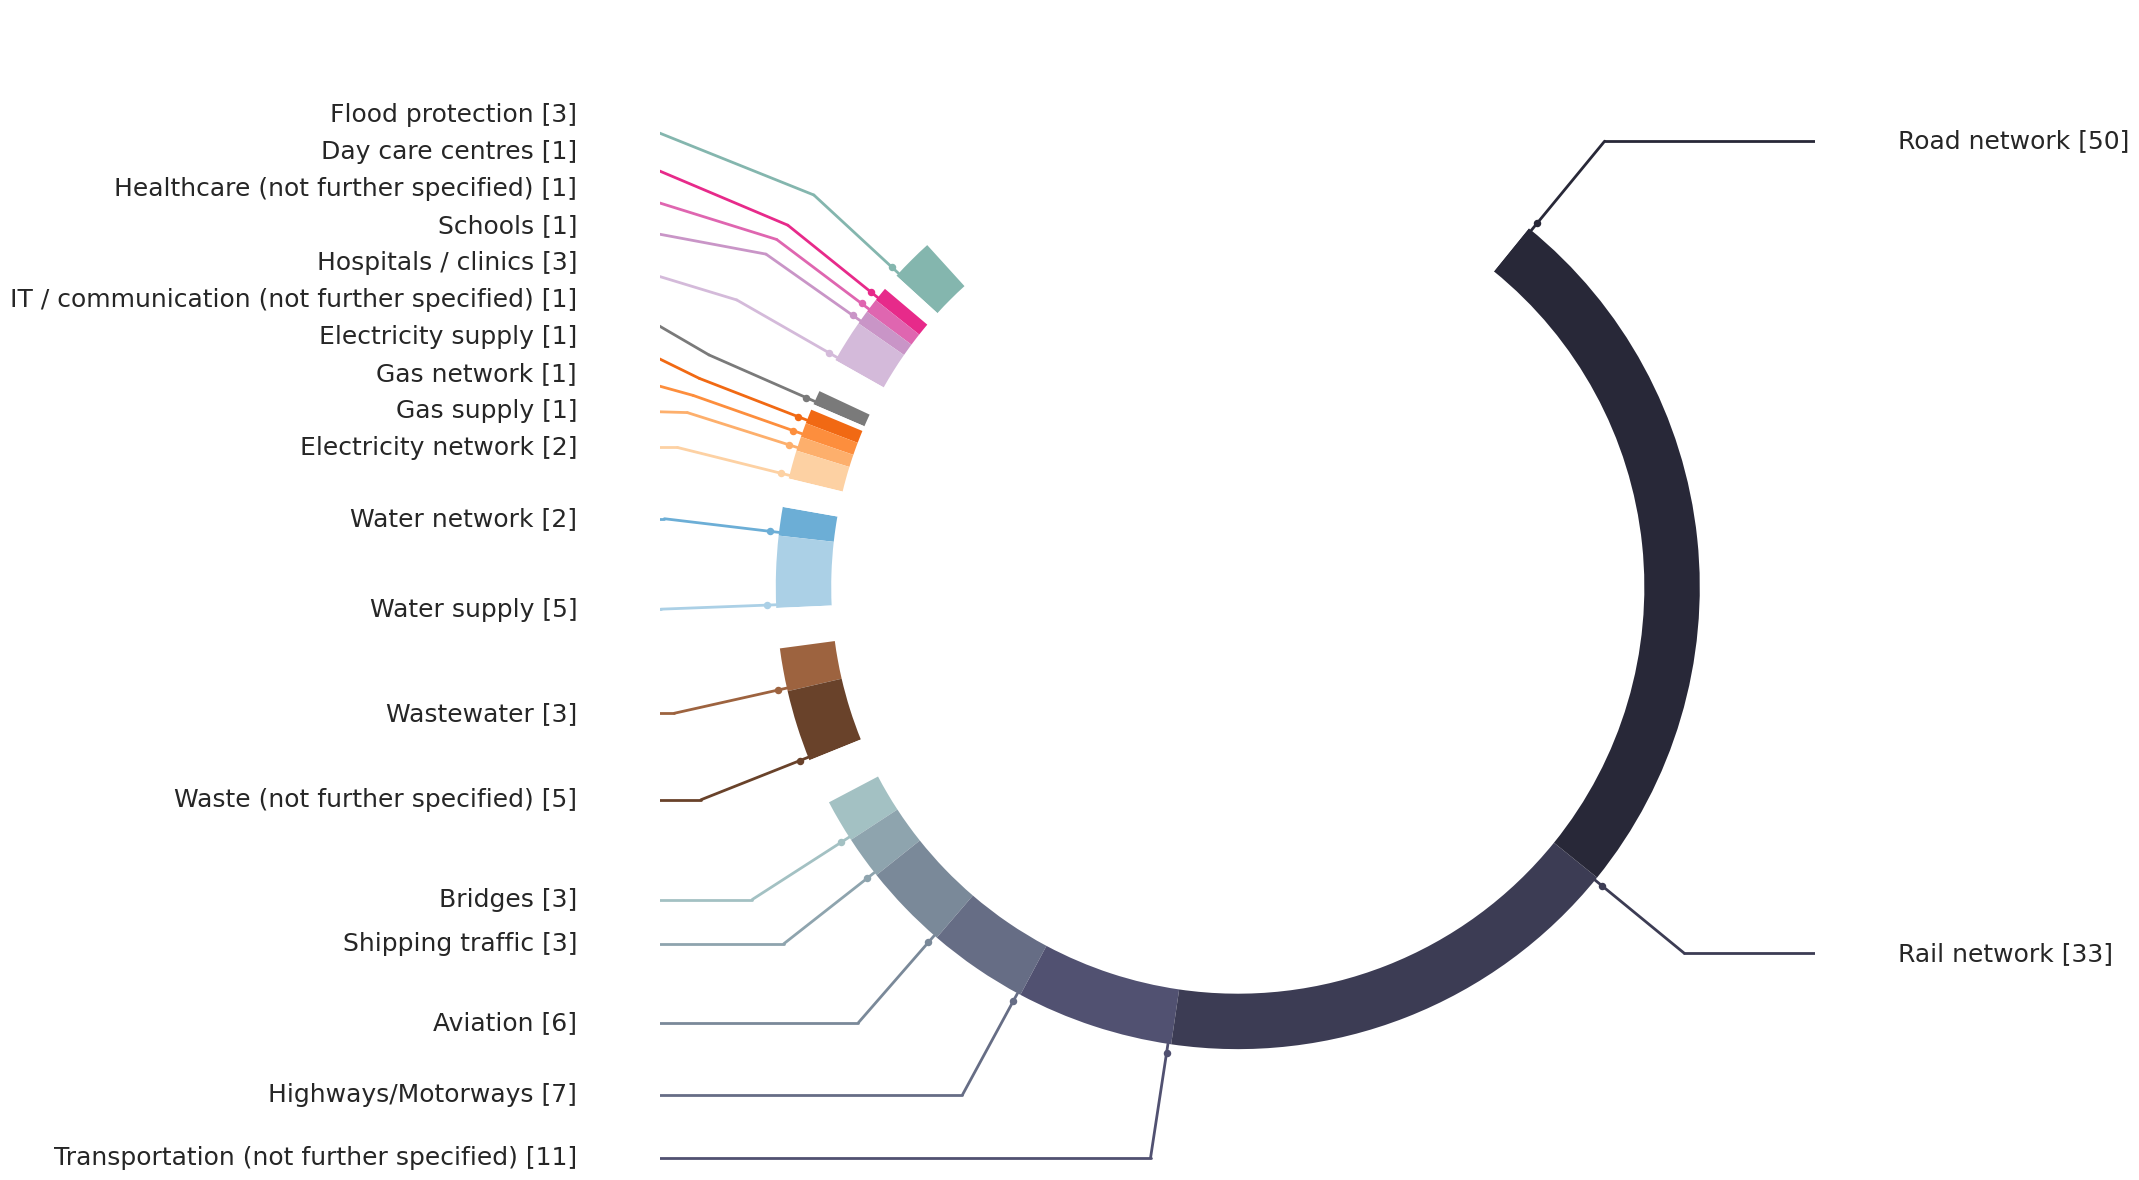

In [362]:
import matplotlib.pyplot as plt
import seaborn as sns


# --- Seaborn style ---
sns.set_theme(style="white", context="talk")

## Prep - create sector and subsector ("group") columns with nice labels 
df_plot = df_pred.copy(deep=True)
# nice lables for CI group (ie Ci subsector) and sector
df_plot["infrastructure_group"] = df_plot["infrastructure_group"].map(cigroup_labels)  # non-matched entries are set to NAN
df_plot["infrastructure_sector"] = df_plot["infrastructure_group"].str.split(" - ").str[0]


# # --- Aggregate data correctly ---
df_plot = (
    df_plot.groupby(["infrastructure_sector", "infrastructure_group"]).size().reset_index(name="count")
)


# Sort by group then value (important for visual grouping)
df_plot = df_plot.sort_values(
    ["infrastructure_sector", "count"],
    ascending=[False, True]
)



labels = df_plot["infrastructure_group"]
sizes = df_plot["count"]
groups = df_plot["infrastructure_sector"]
unique_sectors = groups.unique()

base_palettes = {
    "Transportation": "bone_r", #"Greys",
    "Energy": "Oranges_r",
    "Water": "Blues_r",
    "Structural protection measures": "BrBG_d", # "cividis_d", # "Greens_d",
    "Waste": "copper_r",
    "Social": "PuRd_r",
    "Other": "Greys_r",
    "IT / Communication": "Purples_r",
    "gap": "White"  # for the gap piece
}


## Sector colors
sector_palettes = {}

for sector in unique_sectors:
    n = (groups == sector).sum()
    palette_name = base_palettes.get(sector, "Greys")

    # soft gradient (skip very light colors)
    palette = sns.color_palette(palette_name, n + 3)[2:]
    sector_palettes[sector] = palette

# Assign colors
colors = []
counters = {s: 0 for s in unique_sectors}
for s in groups:
    colors.append(sector_palettes[s][counters[s]])
    counters[s] += 1


## Sectors
sizes_with_gaps = []
colors_with_gaps = []
meta = []  # 🔥 keeps mapping to original data

gap_fraction = 0.4

for sector in unique_sectors:
    sector_df = df_plot[df_plot["infrastructure_sector"] == sector]

    for j, (_, row) in enumerate(sector_df.iterrows()):
        sizes_with_gaps.append(row["count"])
        colors_with_gaps.append(sector_palettes[sector][j])

        meta.append({
            "label": row["infrastructure_group"].split(" - ")[1],
            "size": row["count"],
            "color": sector_palettes[sector][j],
            "is_gap": False
        })

    # add sector gap
    gap_size = sector_df["count"].sum() * gap_fraction
    sizes_with_gaps.append(gap_size)
    colors_with_gaps.append((1, 1, 1, 1))

    meta.append({
        "is_gap": True
    })

# Now rebuild colors in same order
colors_with_gaps = []
for sector in unique_sectors:
    sector_df = df_plot[df_plot["infrastructure_sector"] == sector]
    for i in range(len(sector_df)):
        colors_with_gaps.append(sector_palettes[sector][i])
    colors_with_gaps.append((1, 1, 1, 1))  # gap color


## Gap piece
# gap_size = 50 # df_plot["count"].sum() * 0.2  # controls how open it is (10–25% works well)
gap_size = df_plot["count"].sum() * 0.3  # controls how open it is (10–25% works well)

sizes_with_gap = list(df_plot["count"]) + [gap_size]
colors_with_gap = colors + [(1, 1, 1, 0)]  # fully transparent


##### PLOT 

fig, ax = plt.subplots(figsize=(15, 15))

## Actual donut chart
wedges, _ = ax.pie(
    sizes_with_gaps,
    colors=colors_with_gaps,
    startangle=170,
    wedgeprops=dict(width=0.12, edgecolor="white", linewidth=0)
)

# # --- Leader lines at END of each segment ---
# real_wedges = wedges[:-1]
real_indices = [i for i, lbl in enumerate(labels_with_gaps) if lbl is not None]
real_wedges = [wedges[i] for i in real_indices]


# --- Collect positions first ---

label_data = []

for i, wedge in enumerate(wedges):
    if meta[i]["is_gap"]:
        continue  # 🔥 skip gaps safely

    angle = wedge.theta2 - 0.4
    rad = np.deg2rad(angle)

    x, y = np.cos(rad), np.sin(rad)

    start = (x * 1.0, y * 1.0)
    mid = (x * 1.25, y * 1.25)

    end_x = 1.35 if x > 0 else -1.35
    text_x = end_x + 0.08 if x > 0 else end_x - 0.08

    label_data.append({
        "i": i,
        "start": start,
        "mid": mid,
        "end_x": end_x,
        "text_x": text_x,
        "end_y": mid[1],
        "side": "right" if x > 0 else "left"
    })

# Split left/right
left = [d for d in label_data if d["side"] == "left"]
right = [d for d in label_data if d["side"] == "right"]

import src.visualization as v

left = v.adjust_positions(left)
right = v.adjust_positions(right)

# Merge back
label_data = left + right

# # --- Draw lines + labels ---
for d in label_data:
    i = d["i"]
    m = meta[i]

    align = "left" if d["side"] == "right" else "right"

    ax.plot([d["start"][0], d["mid"][0]],
            [d["start"][1], d["mid"][1]],
            color=m["color"], lw=2)

    ax.plot([d["mid"][0], d["end_x"]],
            [d["mid"][1], d["end_y"]],
            color=m["color"], lw=2)

    ax.text(
        d["text_x"],
        d["end_y"],
        f"{m['label']} [{m['size']}]",
        ha=align,
        va="center",
        fontsize=18
    )

    # Anchor point on donut (slightly outside ring)
    anchor_x = d["start"][0] * 1.02
    anchor_y = d["start"][1] * 1.02
    ax.scatter(anchor_x, anchor_y, color=m["color"], s=15, zorder=3)
    # df_plot = (
    #     df_plot
    #     .groupby(["infrastructure_sector", "infrastructure_group"])
    #     .size()
    #     .reset_index(name="count")
    # )
    


'Water supply'

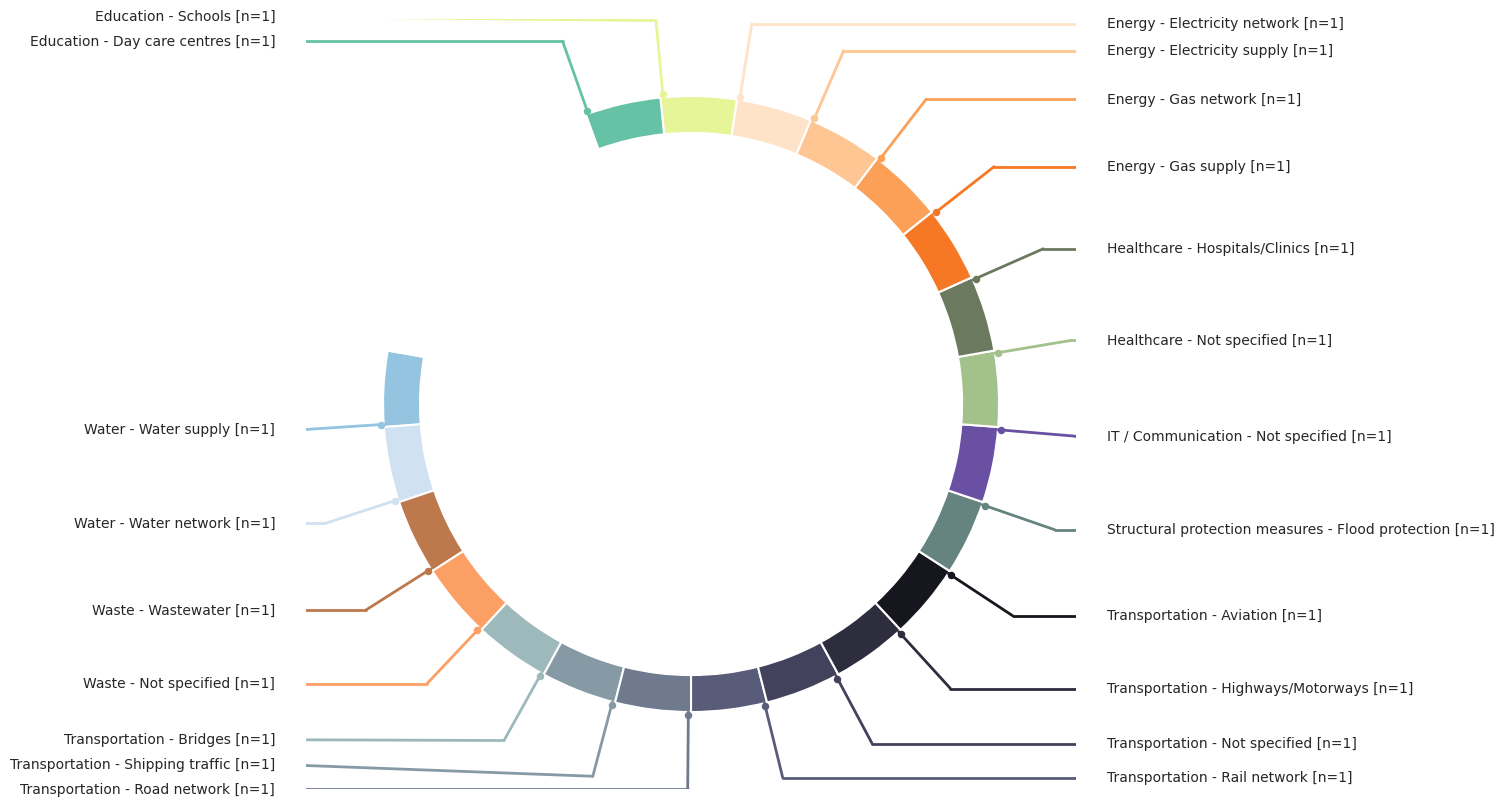

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns


# # --- Seaborn style ---
# sns.set_theme(style="white", context="talk")


# # # --- Aggregate data correctly ---
# df_plot = (
#     df_plot.groupby(["infrastructure_sector", "infrastructure_group"]).size().reset_index(name="count")
# )#.sort_values(["infrastructure_sector", "infrastructure_group"], ascending=True)


# # Sort by group then value (important for visual grouping)
# df_plot = df_plot.sort_values(
#     ["infrastructure_sector"],
#     # ["infrastructure_sector", "count"],
#     ascending=[False]
#     # ascending=[False, False]
# )
# # df_pred_plot = df_pred.groupby(["infrastructure_sector"])["infrastructure_group"].count().reset_index(name="infrastructure_group").sort_values(["infrastructure_group"], ascending=True)



# labels = df_plot["infrastructure_group"]
# sizes = df_plot["count"]
# groups = df_plot["infrastructure_sector"]
# unique_sectors = groups.unique()

# base_palettes = {
#     "Transportation": "bone_r", #"Greys",
#     "Energy": "Oranges_r",
#     "Water": "Blues_r",
#     "Structural protection measures": "BrBG_d", # "cividis_d", # "Greens_d",
#     "Waste": "copper",
#     "IT / Communication": "Purples",
#     "Other": "Greys",
#     "Healthcare": "Spectral_d",
#     "Education": "Spectral",
#     "gap": "White"  # for the gap piece
# }


# ## Sector colors
# sector_palettes = {}

# for sector in unique_sectors:
#     n = (groups == sector).sum()
#     palette_name = base_palettes.get(sector, "Greys")

#     # soft gradient (skip very light colors)
#     palette = sns.color_palette(palette_name, n + 2)[2:]
#     sector_palettes[sector] = palette

# # Assign colors
# colors = []
# counters = {s: 0 for s in unique_sectors}
# for s in groups:
#     colors.append(sector_palettes[s][counters[s]])
#     counters[s] += 1


# ## Sectors
# sizes_with_gaps = []
# colors_with_gaps = []
# labels_with_gaps = []

# gap_fraction = 0.04  # small gap between sectors

# for sector in unique_sectors:
#     sector_df = df_plot[df_plot["infrastructure_sector"] == sector]

#     # Add all subgroup slices (NO gaps inside)
#     for _, row in sector_df.iterrows():
#         sizes_with_gaps.append(row["count"])
#         labels_with_gaps.append(row["infrastructure_group"])
    
#     # Add ONE gap after each sector
#     gap_size = sector_df["count"].sum() * gap_fraction
#     sizes_with_gaps.append(gap_size)
#     colors_with_gaps.append((1, 1, 1, 1))  # white gap
#     labels_with_gaps.append(None)

# # Now rebuild colors in same order
# colors_with_gaps = []
# for sector in unique_sectors:
#     sector_df = df_plot[df_plot["infrastructure_sector"] == sector]
#     for i in range(len(sector_df)):
#         colors_with_gaps.append(sector_palettes[sector][i])
#     colors_with_gaps.append((1, 1, 1, 1))  # gap color


# ## Gap piece
# gap_size = df_plot["count"].sum() * 0.2  # controls how open it is (10–25% works well)

# sizes_with_gap = list(df_plot["count"]) + [gap_size]
# colors_with_gap = colors + [(1, 1, 1, 0)]  # fully transparent


# ##### PLOT 

# fig, ax = plt.subplots(figsize=(10, 10))

# ## Actual donut chart
# wedges, _ = ax.pie(
#     sizes_with_gap,          # ← use sizes WITH gap
#     colors=colors_with_gap,  # ← use colors WITH gap
#     startangle=170,          # rotate so gap is on the left
#     wedgeprops=dict(width=0.12, edgecolor="white", linewidth=1.5)
# )


# # # --- Leader lines at END of each segment ---
# real_wedges = wedges[:-1]
# # real_indices = [i for i, lbl in enumerate(labels_with_gaps) if lbl is not None]
# #real_wedges = [wedges[i] for i in real_indices]


# label_data = []

# # --- Collect positions first ---
# for i, wedge in enumerate(real_wedges):
# # for idx, wedge in zip(real_indices, real_wedges):
#     # i = idx  # use correct index
#     angle = wedge.theta2 - 0.5
#     rad = np.deg2rad(angle)

#     x, y = np.cos(rad), np.sin(rad)

#     start = (x * 1.0, y * 1.0)
#     mid = (x * 1.25, y * 1.25)

#     #Annotation placing
#     label_offset = 0.08  # small horizontal spacing from line
#     end_x = (1.35 if x > 0 else -1.35)
#     text_x = end_x + label_offset if x > 0 else end_x - label_offset
#     end_y = mid[1]
#     # end_x = 1.6 if x > 0 else -1.6
#     # end_y = mid[1]

#     side = "right" if x > 0 else "left"

#     label_data.append({
#         "i": i,
#         "start": start,
#         "mid": mid,
#         "end_x": end_x,
#         "end_y": end_y,
#         "side": side
#     })

# # Split left/right
# left = [d for d in label_data if d["side"] == "left"]
# right = [d for d in label_data if d["side"] == "right"]

# import src.visualization as v

# left = v.adjust_positions(left)
# right = v.adjust_positions(right)

# # Merge back
# label_data = left + right

# # # --- Draw lines + labels ---
# for d in label_data:
#     i = d["i"]

#     align = "left" if d["side"] == "right" else "right"


#     # redraw line to adjusted label position
#     ax.plot([d["start"][0], d["mid"][0]],
#             [d["start"][1], d["mid"][1]],
#             color=colors[i], lw=2)

#     ax.plot([d["mid"][0], d["end_x"]],
#             [d["mid"][1], d["end_y"]],
#             color=colors[i], lw=2)

#     ax.text(
#         d["end_x"],
#         d["end_y"],
#         f"{labels.iloc[i]} [n={sizes.iloc[i]}]",
#         ha=align,
#         va="center",
#         fontsize=10
#     )

#     # Anchor point on donut (slightly outside ring)
#     anchor_x = d["start"][0] * 1.01
#     anchor_y = d["start"][1] * 1.01
#     ax.scatter(anchor_x, anchor_y, color=colors[i], s=15, zorder=3)


* a map of the locations of the infrastrucutre damages 


In [193]:
df_plot = df_pred

In [ ]:
## get search bbox based on min and max coords
coords_list = [[float(v[0]), float(v[1])] for v in df_plot.coords.values()]
get_bbox(coords_list)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from geopy.geocoders import Nominatim
import contextily as ctx


# df_plot = df_plot[["location", "infrastructure_group"]].dropna()

geolocator = Nominatim(user_agent="ahr_map")

def geocode(loc):
    # try:
    #     location = geolocator.geocode(f"{loc}, Germany") # this should handle also othercountires (or even regions)
    #     return Point(location.longitude, location.latitude) if location else None
    # except:
    #     return None
    try:
        location = geolocator.geocode(
            f"{loc}",
            viewbox=[Point(), Point()]
            bounded=True,
            namedetails=True   # allow vairations                          
        )  # NOTE loc needs to be in utf-8 (eg. Bad-Münsterahr)

        # location = geolocator.geocode(f"{loc}, Germany")  # NOTE loc needs to be in utf-8 (eg. Bad-Münsterahr)
        return Point(location.longitude, location.latitude) if location else None
        # location = geolocator.geocode(f"{loc}, Ahrweiler, Germany")  # NOTE loc needs to be in utf-8 (eg. Bad-Münsterahr)
        # if location:
            # return pd.Series([location.latitude, location.longitude])
    except:
        return None
        # try:
        #     # location = geolocator.geocode(f"{loc}, Spain")
        #     return Point(location.longitude, location.latitude) if location else None
        #     # if location:
        #     #     return pd.Series([location.latitude, location.longitude])
        # except:
        #     return None
        # #     #return pd.Series([None, None])
    
df_plot["geometry"] = df_plot["location"].apply(geocode)
df_points = df_plot.dropna(subset=["geometry"])


In [208]:
gdf_points = gpd.GeoDataFrame(df_points, geometry="geometry", crs="EPSG:4326")


In [ ]:
df_plot.info()

gdf_points.location.unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   citation_id                143 non-null    object
 1   chunk_id                   143 non-null    object
 2   infrastructure_type        143 non-null    object
 3   infrastructure_group       143 non-null    object
 4   damage                     94 non-null     object
 5   location                   143 non-null    object
 6   ci_entity                  78 non-null     object
 7   geo_entity                 78 non-null     object
 8   coord_potential_locations  143 non-null    object
 9   chunk_text                 143 non-null    object
 10  infrastructure_type_org    130 non-null    object
 11  damage_org                 92 non-null     object
 12  locations_org              111 non-null    object
 13  coords                     94 non-null     object
 14  coords_coa

array(['Britain', 'UK', 'Spain', 'Saale', 'Rosenheim', 'Raubling',
       'Saxony-Anhalt', 'Bitterfeld', 'Den Helder', 'Utrecht',
       'Rhineland-Palatinate', 'Spa', 'Belgium', 'Netherlands', 'tracks'],
      dtype=object)

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/.venv/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 23 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


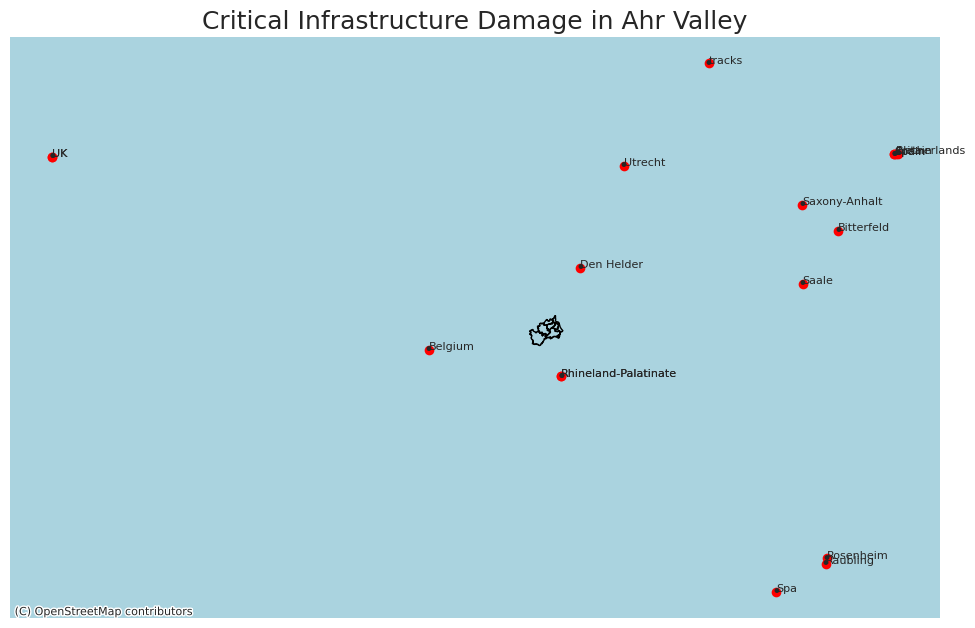

In [231]:


# Example: load shapefile (replace gadm41_DEU_ your path)
gdf_regions = gpd.read_file("../../data/visualization/admin_borders/gadm41_DEU_3.shp") # ahrweiler, bad kissingen

# Filter to Ahr valley region (Ahrweiler district)
gdf_regions = gdf_regions[gdf_regions["NAME_2"].str.contains("Ahrweiler", na=False)]
# gdf_cities = gdf_regions[gdf_regions["NAME_3"].str.contains("Sinzig", na=False)] # example

# Spatial join: assign each point to a region
gdf_points = gdf_points.to_crs(gdf_regions.crs)

gdf_joined = gpd.sjoin(gdf_points, gdf_regions, how="left", predicate="within")

icon_map = {
    "energy": "⚡",
    "transport": "🚧",
    "water": "💧",
    "digital": "📡",
    "health": "🏥"
}

fig, ax = plt.subplots(figsize=(12, 12))

# --- Plot regions (polygons) ---
gdf_regions.boundary.plot(ax=ax, linewidth=1, color="black")

# --- Plot points ---
gdf_points.plot(ax=ax, color="red", markersize=30)

# --- Add city labels ---
for idx, row in gdf_points.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        row["location"],
        fontsize=8
    )

# --- Add infrastructure icons ---
for idx, row in gdf_points.iterrows():
    icon = icon_map.get(str(row["infrastructure_group"]).lower(), "•")

    ax.text(
        row.geometry.x,
        row.geometry.y,
        icon,
        fontsize=12,
        ha="center",
        va="center"
    )

# --- Add basemap ---
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Critical Infrastructure Damage in Ahr Valley")

plt.show()

In [ ]:
## clustered MAP

import pandas as pd
import folium
from folium.plugins import MarkerCluster
from geopy.geocoders import Nominatim

df_plot_2 = df_plot.copy(deep=True)

geolocator = Nominatim(user_agent="ahr_cluster_map")

def geocode(loc):
    try:
        location = geolocator.geocode(f"{loc}, Ahrweiler, Germany")
        if location:
            return Point(location.longitude, location.latitude) if location else None
            #return pd.Series([location.latitude, location.longitude])
    except:
        return None
        # return pd.Series([None, None])

# df_plot_2[["lat", "lon"]] = df_plot_2["location"].apply(geocode)
df_plot_2["geometry"] = df_plot_2["location"].apply(geocode)
df_points_2 = df_plot_2.dropna(subset=["geometry"])

icon_map = {
    "energy": ("bolt", "orange"),
    "transport": ("road", "blue"),
    "water": ("tint", "cadetblue"),
    "digital": ("signal", "purple"),
    "health": ("plus", "red"),
}

m = folium.Map(location=[50.5, 7.0], zoom_start=10)
marker_cluster = MarkerCluster().add_to(m)

## ad clustered markers
for _, row in df_plot_2.iterrows():
    group = str(row["infrastructure_group"]).lower()
    icon_name, color = icon_map.get(group, ("info-sign", "gray"))

    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=f"{row['location']}<br>{row['infrastructure_group']}",
        icon=folium.Icon(icon=icon_name, prefix="fa", color=color)
    ).add_to(marker_cluster)
# save + open in browser
m.save("ahr_infrastructure_cluster_map.html")

In [ ]:
df_plot["location"]#.apply(geocode)
# df_plot[["lat", "lon"]] = df_plot["location"].apply(geocode)
# df_plot = df_plot.dropna(subset=["lat", "lon"])


* Left overs - plotting

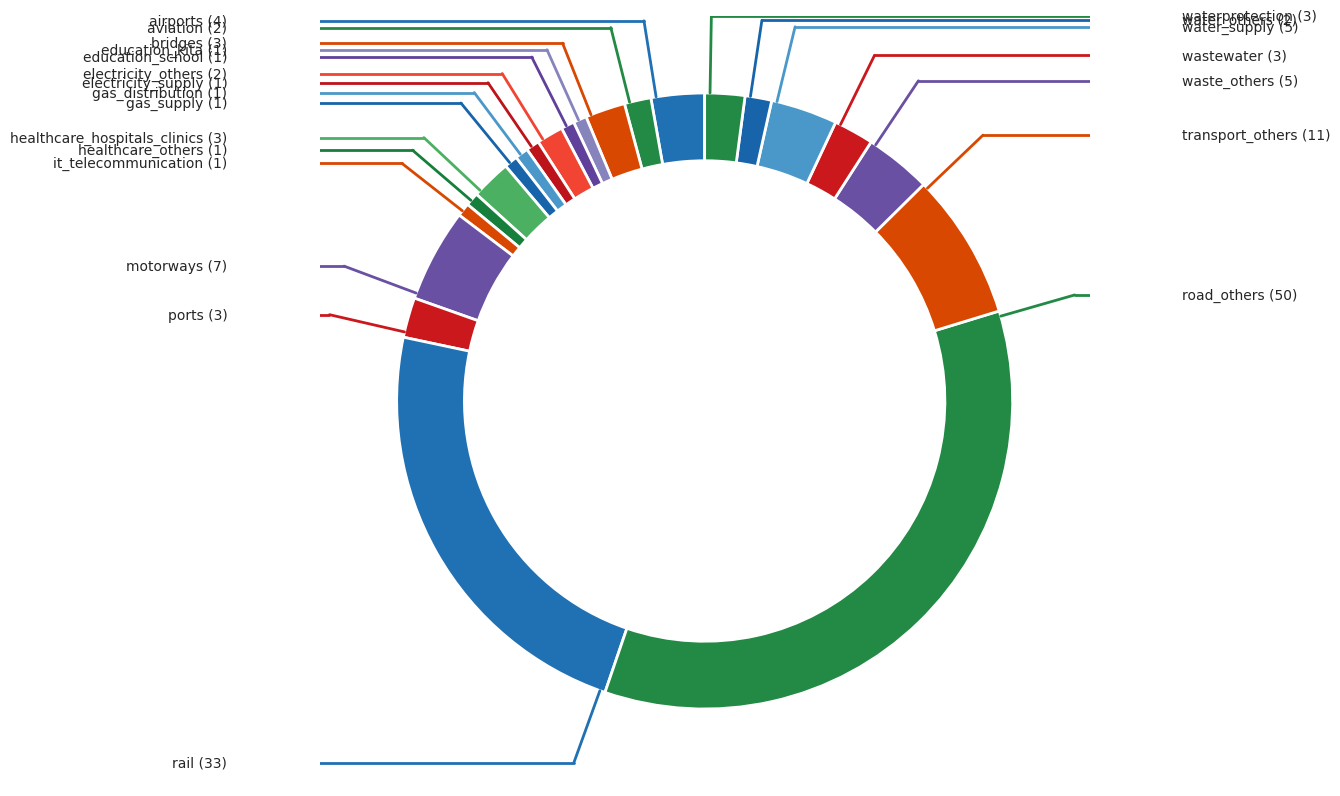

In [300]:
# * histogram plot showing which are most common in the prediction set

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- Load your CSV ---
# Example CSV should have columns: category, value

# df_pred_plot = df_pred.groupby(["infrastructure_sector"])["infrastructure_group"].count().reset_index(name="infrastructure_group").sort_values(["infrastructure_group"], ascending=True)
# # df_pred[df_pred["infrastructure_group"].sort_values(ascending=False)]
# labels = df_pred_plot["infrastructure_group"].value_counts().index.tolist()  # get category labels in order of frequency
# sizes = df_pred_plot["infrastructure_group"].values
# groups = df_pred_plot["infrastructure_sector"]

df_plot = df_pred.copy()
# --- Aggregate data correctly ---
df_plot = (
    df_plot
    .groupby(["infrastructure_sector", "infrastructure_group"])
    .size()
    .reset_index(name="count")
)

# Sort by group then value (important for visual grouping)
df_plot = df_plot.sort_values(
    ["infrastructure_sector", "count"],
    ascending=[True, False]
)

labels = df_plot["infrastructure_group"]
sizes = df_plot["count"]
groups = df_plot["infrastructure_sector"]

# --- Seaborn style ---
sns.set_theme(style="white", context="talk")

# --- Grouped color palettes (soft infographic style) ---
unique_groups = groups.unique()
base_palettes = ["Blues", "Greens", "Oranges", "Purples", "Reds"]

group_palettes = {}
for i, group in enumerate(unique_groups):
    n = (groups == group).sum()
    # Use lighter range for infographic feel
    palette = sns.color_palette(base_palettes[i % len(base_palettes)], n + 2)[2:]
    group_palettes[group] = palette

# Assign colors in order
colors = []
counters = {g: 0 for g in unique_groups}

for g in groups:
    colors.append(group_palettes[g][counters[g]])
    counters[g] += 1

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

wedges, _ = ax.pie(
    sizes,
    colors=colors,
    startangle=90,
    wedgeprops=dict(
        width=0.22,           # thinner ring (closer to infographic)
        edgecolor="white",    # creates separation between segments
        linewidth=2
    )
)

# --- Leader lines at END of each segment ---
for i, wedge in enumerate(wedges):
    # Use END of wedge instead of center
    angle = wedge.theta2 -1
    rad = np.deg2rad(angle)

    x, y = np.cos(rad), np.sin(rad)

    # Start exactly at outer edge
    r_outer = 1.0
    r_mid = 1.25

    start = (x * r_outer, y * r_outer)
    mid = (x * r_mid, y * r_mid)

    # Push labels further out for clarity
    end_x = 1.55 if x > 0 else -1.55
    end_y = mid[1]

    align = "left" if x > 0 else "right"

    # Draw leader lines (now anchored at segment END)
    ax.plot([start[0], mid[0]], [start[1], mid[1]],
            color=colors[i], lw=2)
    ax.plot([mid[0], end_x], [mid[1], end_y],
            color=colors[i], lw=2)

    # Label
    ax.text(
        end_x,
        end_y,
        f"{labels.iloc[i]} ({sizes.iloc[i]})",
        ha=align,
        va="center",
        fontsize=10
    )

In [ ]:
# * histogram plot showing which are most common in the prediction set

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- Load your CSV ---
# Example CSV should have columns: category, value

df_pred_plot = df_pred.groupby(["infrastructure_sector"])["infrastructure_group"].count().reset_index(name="infrastructure_group").sort_values(["infrastructure_group"], ascending=True)
# df_pred[df_pred["infrastructure_group"].sort_values(ascending=False)]
labels = df_pred_plot["infrastructure_group"].value_counts().index.tolist()  # get category labels in order of frequency
sizes = df_pred_plot["infrastructure_group"].values
groups = df_pred_plot["infrastructure_sector"]


# --- Seaborn styling ---
sns.set_theme(style="white")

# --- Create color mapping per group ---
unique_groups = groups.unique()
group_palettes = {}

# Assign a base palette per group
base_palettes = ["Blues", "Greens", "Reds", "Purples", "Oranges"]

for i, group in enumerate(unique_groups):
    count = sum(groups == group)
    palette = sns.color_palette(base_palettes[i % len(base_palettes)], count)
    group_palettes[group] = palette

# Flatten colors in correct order
colors = []
group_counters = {g: 0 for g in unique_groups}

for g in groups:
    colors.append(group_palettes[g][group_counters[g]])
    group_counters[g] += 1

# --- Create donut chart ---
fig, ax = plt.subplots(figsize=(8, 8))

wedges, _ = ax.pie(
    sizes,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.25)  # thin ring
)

# --- Leader lines ---
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    angle_rad = np.deg2rad(angle)

    x = np.cos(angle_rad)
    y = np.sin(angle_rad)

    start_x, start_y = x * 1.0, y * 1.0
    mid_x, mid_y = x * 1.2, y * 1.2
    end_x = 1.4 if x > 0 else -1.4
    end_y = mid_y

    align = "left" if x > 0 else "right"

    # Colored leader lines
    ax.plot([start_x, mid_x], [start_y, mid_y], color=colors[i], lw=1.5)
    ax.plot([mid_x, end_x], [mid_y, end_y], color=colors[i], lw=1.5)

    # Label includes group (optional)
    ax.text(
        end_x,
        end_y,
        "sss", #f"{labels[i]} ({sizes[i]})",
        ha=align,
        va="center",
        fontsize=10
    )

# --- Final styling ---
ax.set(aspect="equal")
plt.title("Donut Chart with Grouped Color Shades", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:

# --- Seaborn styling ---
sns.set_theme(style="white")

# --- Create color mapping per group ---
unique_groups = groups.unique()
group_palettes = {}

# Assign a base palette per group
base_palettes = ["Blues", "Greens", "Reds", "Purples", "Oranges"]

for i, group in enumerate(unique_groups):
    count = sum(groups == group)
    palette = sns.color_palette(base_palettes[i % len(base_palettes)], count)
    group_palettes[group] = palette

# Flatten colors in correct order
colors = []
group_counters = {g: 0 for g in unique_groups}

for g in groups:
    colors.append(group_palettes[g][group_counters[g]])
    group_counters[g] += 1

# --- Create donut chart ---
fig, ax = plt.subplots(figsize=(8, 8))

wedges, _ = ax.pie(
    sizes,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.25)  # thin ring
)

# --- Leader lines ---
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    angle_rad = np.deg2rad(angle)

    x = np.cos(angle_rad)
    y = np.sin(angle_rad)

    start_x, start_y = x * 1.0, y * 1.0
    mid_x, mid_y = x * 1.2, y * 1.2
    end_x = 1.4 if x > 0 else -1.4
    end_y = mid_y

    align = "left" if x > 0 else "right"

    # Colored leader lines
    ax.plot([start_x, mid_x], [start_y, mid_y], color=colors[i], lw=1.5)
    ax.plot([mid_x, end_x], [mid_y, end_y], color=colors[i], lw=1.5)

    # Label includes group (optional)
    ax.text(
        end_x,
        end_y,
        f"{labels[i]} ({sizes[i]})",
        ha=align,
        va="center",
        fontsize=10
    )

# --- Final styling ---
ax.set(aspect="equal")
plt.title("Donut Chart with Grouped Color Shades", fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:

# # --- Seaborn styling ---
# sns.set_theme(style="white")
# colors = sns.color_palette("tab10", len(df_pred))

# # --- Create donut chart ---
# fig, ax = plt.subplots(figsize=(8, 8))

# wedges, _ = ax.pie(
#     sizes,
#     colors=colors,
#     startangle=90,
#     wedgeprops=dict(width=0.25)  # thinner ring
# )

# # --- Add colored leader lines and labels ---
# for i, wedge in enumerate(wedges):
#     angle = (wedge.theta2 + wedge.theta1) / 2
#     angle_rad = np.deg2rad(angle)

#     # Outer edge of donut (exact end of subsection)
#     x = np.cos(angle_rad)
#     y = np.sin(angle_rad)

#     # Start at outer edge of donut
#     start_x = x * 1.0
#     start_y = y * 1.0

#     # Extend outward
#     mid_x = x * 1.2
#     mid_y = y * 1.2

#     # Horizontal extension for label alignment
#     end_x = 1.4 if x > 0 else -1.4
#     end_y = mid_y

#     align = "left" if x > 0 else "right"

#     # Draw two-segment leader line (radial + horizontal)
#     ax.plot([start_x, mid_x], [start_y, mid_y], color=colors[i], lw=1.5)
#     ax.plot([mid_x, end_x], [mid_y, end_y], color=colors[i], lw=1.5)

#     # Add label
#     ax.text(
#         end_x,
#         end_y,
#         f"{labels[i]} ({sizes[i]})",
#         ha=align,
#         va="center",
#         fontsize=10
#     )

# # --- Final styling ---
# ax.set(aspect="equal")
# plt.title("Improved Donut Chart with Colored Leader Lines", fontsize=14)

# plt.tight_layout()
# plt.show()

In [ ]:
!uv lock

#### FIXME: find out which cases model predicted existence, but not in valid DS - maybe due that valid DS is incomppete?

In [ ]:
df_pred.info()

In [ ]:
## fix FPs 

## get all pred cases which 
# rows in df_valid where sentence_reference appears as substring in at least one df_pred.chunk_text
chunk_texts = df_pred["chunk_text"].dropna().astype(str)

df_valid_2 = df_valid[
    df_valid["sentence_reference"].fillna("").astype(str).apply(
        lambda s: any(s and s in chunk for chunk in chunk_texts)
    )
]

df_valid_2 # .shape (28, 7)

In [ ]:
# cases where pred-case exist but no fitting valid case could be found based on sentence_reference
df_pred_not_in_valid = df_pred[df_pred['chunk_text'].str.contains('|'.join(df_valid["sentence_reference"]), regex=True)]
print(df_pred_not_in_valid.id_pred.value_counts())
df_pred_not_in_valid.head(10)

# TODO TODO
## documents where model found many CI cases as false-alarms:
# maybe i need to recheck those docs and make df_valid more complete
# print(df_pred_not_in_valid.groupby("citation_id").count())
# citation_id                                                            
# ABC 2024                        4
# Containerlift 2024             24
# European Investment Bank 2025  21
# Ferlita 2023                   22
# Koks 2022                      10


In [ ]:
df_valid

#### FIXME: FPs and FNs

In [ ]:
## TPs + FNs should be == len(df_valid.ci) == 67
        
# TPs 
tps = df_smltry_selmax.loc[df_smltry_selmax["impact_sim_identical"] == 1]

# FNs
df_valid_pred_missed_docs = df_valid[df_valid["publication_id"].isin(df_pred["citation_id"]) == False]
df_valid_cases_missed_by_model = df_smltry_selmax[df_smltry_selmax.duplicated(subset="id_pred", keep="first")]
fns = pd.concat([df_valid_pred_missed_docs, df_valid_cases_missed_by_model], ignore_index=True, axis=0)

print(tps.shape[0], fns.shape[0])
print(tps.shape[0] + fns.shape[0])

# --> 8 cases in FNs are too definitly too much --> fix FN calculation



## FPs should be == len(df_pred.ci) - TPs

## FPs
fps = df_smltry_selmax.loc[df_smltry_selmax["impact_sim_identical"] == 0]

print(len(df_pred.infrastructure_type), tps.shape[0], fps.shape[0])
print(len(df_pred.infrastructure_type) - tps.shape[0])




In [ ]:
# TODO fix FPs
# get records where model predicted presence of impacts but they actually does not exist
# here as definition, that when simi=0 (or below threshold) then model predicted wrongly
df_smltry_not_sim = df_smltry_selmax.loc[df_smltry_selmax["impact_sim_identical"] == 0]

# TODO
# add also as Fps were model_pred case exist but no fitting_vlaid case could be found

# idea: 
# get all df_pred cases where chunk text not occurs in valid.sentece_text

df_pred_not_in_valid = df_pred[df_pred["chunk_text"].isin(df_valid["sentence_reference"])== False]
print(df_pred.shape, df_pred_not_in_valid.shape)
# df_pred_not_in_valid

In [ ]:
# df_valid__pred_no_thresh.id_pred.nunique()
df_pred_valid_no_thresh.id_pred.nunique()

In [ ]:
# df_valid__pred_no_thresh.info()
# df_pred_valid_no_thresh.info()  # 67 valid * 921 pred = 61707
# df_pred_valid_no_thresh.drop("chunk_text_pred", axis=1).sort_values("id_pred").iloc[0:100]
# df_pred_valid_no_thresh.groupby("id_pred").first().sort_values("text_similarity", ascending=False).iloc[0:100]
# df_valid__pred_no_thresh.groupby("id_valid").first().sort_values("text_similarity", ascending=False).iloc[0:100]
#df_valid__pred_no_thresh.sort_values("id_valid", ascending=False).sort_values("text_similarity", ascending=False).iloc[0:100]
#df_valid__pred_no_thresh.groupby("id_valid").first().sort_values("text_similarity", ascending=False).iloc[0:100]
df_valid__pred_no_thresh.groupby("id_valid").apply(lambda x: x.loc[x["text_similarity"].idxmax()])


In [ ]:
# fns

In [ ]:
## FNs 
df_smltry_selmax.loc[df_smltry_selmax.duplicated("id_pred")]
## --> ISSUE: this df (cases of highest sim) should NOT have duplicated cases of predictions -> maybe have to group based on id_pred and not id_valid

## try to fix issue
## --> currently i think this should group based on valid cases to measure were model predicted the same or missed info (ie FNs)
# df_smltry_selmax_p = df_smltry_selmax
# mask of rows with highest similarity score for each set of preds with unique valid case (droplevel(0) remove multiindex)
mask = df_smltry_all.loc[df_smltry_all.id_valid==37].groupby("id_valid").apply(lambda x: x==x["impact_sim_identical"].max()).droplevel(0)
df_smltry_selmax_p = df_smltry_all.where(mask.impact_sim_identical==mask.impact_sim_identical.max()).dropna(how="all") # drop cases which have not highest similairty score
# df_smltry_selmax_p = df_smltry_all.groupby("id_valid").apply(lambda x: x.loc[x["impact_sim_identical"].idxmax()]) # 52 cases
# df_smltry_selmax_p = df_smltry_all.groupby("id_pred").apply(lambda x: x.loc[x["impact_sim_identical"].idxmax()]) # 175 cases
df_smltry_selmax_p.reset_index(drop=True, inplace=True)

## FIXME  df_smltry_all.groupby("id_valid"): should it has duplicated cases of id_pred ? - i dont think so! 
#  bc it means that there model missed cases in valid_set
## --> so all duplicated cases (except one-this is TP or FP) are actual FNs
print(df_smltry_selmax_p.info())
print(df_smltry_selmax_p.id_pred.nunique()  )  # should be len of df
print(df_smltry_selmax_p.duplicated().sum())


# FNs: extracts all duplicates (except first occurrence eg. id_Pred==537 occurs in df_smltry_selmax_p three times (1st case: TP or FP, 2nd and 3rd are FNs)
fns = df_smltry_selmax_p[df_smltry_selmax_p.duplicated(subset="id_pred", keep="first")]

print(fns.info())
fns.id_pred.value_counts()


In [ ]:
# return all cases which has max sim also when max score is shared by multiple rows 
# df_smltry_all.loc[df_smltry_all.groupby("id_valid").transform(lambda x: x==x.max()).astype('bool')].shape
mask = df_smltry_all.loc[df_smltry_all.id_valid==37].groupby("id_valid").apply(lambda x: x==x["impact_sim_identical"].max())
mask = mask.droplevel(0)
#.transform(lambda x: x==x.max())
tt = df_smltry_all.loc[df_smltry_all.id_valid==37]#
tt = tt.where(mask.impact_sim_identical==mask.impact_sim_identical.max()).dropna(how="all") # drop cases which have not highest similairty score

# tt[mask]

# would return only first case of max sim:
#df_smltry_all.loc[df_smltry_all.id_valid==37].groupby("id_valid").apply(lambda x: x.loc[x["impact_sim_identical"].idxmax()]) #


In [ ]:
# FPs. 
print("False alarms (where model predicted ci but no corresponding valid case exists)", 
      len(df_pred["infrastructure_type"])  - len(df_smltry_selmax[df_smltry_selmax["impact_sim_identical"]== 1, "ci_group_pred"])
    )
# Get FPs - cases where model predicted presence of CI (but actually it is absent in valid set)
tt = df_pred.merge(
    # FIXME issue that df_pred_valid_all contains some duplicates where id_pred identical but not valid_entries
    df_smltry_selmax.drop_duplicates(), # safety: make sure that merging is done on 1:1 match
    left_on="id_pred",#["citation_id", "chunk_id","infrastructure_type", "damage", "location"], 
    right_on="id_pred",#["citation_id", "chunk_id_pred", "ci_pred", "damage_pred", "location_pred"],
    how="left",
    indicator=True    # return an extra column indicating which table the row was from.
)
tt = tt.loc[tt["_merge"] == "left_only"].drop(columns=["_merge"])
print("False positives (model predicted CI but no corresponding valid case exists):", len(tt))

In [ ]:
print(df_pred.shape[0])
# print(df_pred_valid_all.info())
print(tt.info())

In [ ]:
df_pred#["infrastructure_type"]

In [ ]:
df_smltry_selmax.info()

In [ ]:
# df_smltry_selmax["impact_sim_identical"] < cos_smlrty_thresh

In [ ]:
# len(df_valid_pred_same_docs["ci1_group"]) 

In [ ]:
# TODO fix FNs
print(df_valid_pred_same_docs.info())
print(df_smltry_selmax[df_smltry_selmax["impact_sim_identical"]==1].info())
# --> FNS should be  23
len(df_valid_pred_same_docs["ci1_group"])  - len(df_smltry_selmax[df_smltry_selmax["impact_sim_identical"]==1]["impact_valid"])

In [ ]:
# #df_valid_pred_same_docs["id_valid"] = df_valid_pred_same_docs.apply(lambda x: f"{x['ci1_group']}_{x['ci1_damage']}_{x['ci1_location']}_{x['sentence_text_valid'][:50]}", axis=1)
# print(df_valid_pred_same_docs["id_valid"].unique().__len__())
# print(df_valid_pred_same_docs.shape[0])
# ## --> check why electricity_others_outages_nan = 3  - (seems correct as sentences_ref are diff). airports_affected_Malaga area=2 are not unique
# df_valid_pred_same_docs[df_valid_pred_same_docs["id_valid"] == "airports_affected_Malaga area"]

# Improve similarity calculation
As all similarity measures - nomatter which emebdding model or kind of cosine similarity measure) were not sufficient eg. port ~ power to similar to port~harbor

Thus, it might be better to first group ci impacts into subgroups e.g .based on HARCI-EU categories,as some kind of postprocessing step before applying the similarity measurements



In [ ]:
df_ner = pd.read_json("./ner_patterns.jsonl/patterns", lines=True)

In [ ]:
# d = {"label":"CI_TYPE","pattern": [{"TEXT": {"REGEX": ".* [Tt]ransport.*"}}, {"LOWER": "sector"}], "subgroup_name":"transport_others"}
# #d["pattern"][0]["TEXT"]["REGEX"] + " " + dd["pattern"][1]["LOWER"]
# d["subgroup_name"]

In [ ]:
import re

# load regular expressions and subgroups from NER patterns as dict
# for general cases and all special cases with "LOWER"-pattern
regexes_1 = [
        {df_ner["pattern"][i][0]["TEXT"]["REGEX"] : df_ner["subgroup_name"][i]}
          for i in range(len(df_ner)) 
            if len(df_ner["pattern"][i])==1 
]
regexes_2 = [
    {df_ner["pattern"][i][0]["TEXT"]["REGEX"] + " " + df_ner["pattern"][i][1]["LOWER"] : df_ner["subgroup_name"][i] }
      for i in range(len(df_ner))
        if len(df_ner["pattern"][i])==2
]
# regexes = regexes_1 | regexes_2
regexes = regexes_1 + regexes_2
regexes[:20]


In [ ]:
for i, r in enumerate(regexes):

    # get regex pattern for CI type (key) and its subgroup (value)
    # NOTE, nice shortcut: get key containing regex by unpacking each dict into list, then get key
    pattern = [*r][0]
    subgroup = r[pattern]

    # assign subgroups to CI records, na=False to remove all records which not match patterns
    mask = df_pred["infrastructure_type"].str.contains(pattern, regex=True, na=False)
    df_pred.loc[mask, "infrastructure_group"] = subgroup

    # assign subgroups to CI records, na=False to remove all records which not match patterns
    mask = df_valid["ci1_type"].str.contains(pattern, regex=True, na=False)
    df_valid.loc[mask, "ci1_group"] = subgroup
    
df_pred

print(df_pred.infrastructure_group.isna().sum())
print(df_pred.infrastructure_group.value_counts())
# df_pred.infrastructure_group.unique()


In [ ]:
print(df_valid.df_valid.isna().sum())
print(df_valid.df_valid.value_counts())
# df_pred.infrastructure_group.unique()

In [ ]:
# s = "dyke" to s2 = "levee", s3 = "dam"
# bge-m3: 0.48  0.54
# all-MIniLM-L6-v2: 0.34 , 0.36  (similar all-mpnet-base-v2)
# gensim word2vec: 0.39 0.40


# s1 = "aviation" s2 = "air traffic"
# word vector spacy: 0.45
# contextual vector spacy: 0.68
# bge-m3: 0.76
# all-MIniLM-L6-v2: xx  (all-mpnet-base-v2: 0.79)
# gensim word2vec: 


# s1 = "power" s2 = "electricity"
# word vector spacy: 0.61
# contextual vector spacy: 0.66
# bge-m3: 
# all-MIniLM-L6-v2: xx   (all-mpnet-base-v2: 0.43)
# gensim word2vec: 0.58


# s1 = "electricity infrastructure" s2 = "electricity"
# word vector spacy: 0.87
# contextual vector spacy: 0.71
# bge-m3: 
# all-MIniLM-L6-v2:   xx  (all-mpnet-base-v2: 0.63)
# gensim word2vec: 


# s1 = "transportation" s2 = "transport infrastructure"
# word vector spacy: 
# contextual vector spacy: 
# bge-m3: 
# all-MIniLM-L6-v2:   xx  (all-mpnet-base-v2: 0.84)
# gensim word2vec: 

# s1 = "port" s2 = "power"  s3= harbour
# bge-m3: 0.58, 0.50
# all-MIniLM-L6-v2: 0.33 , 0.56  (similar all-mpnet-base-v2)
# gensim word2vec: 0.14 0.59

# s1 = "electricity" s2 = "transportation" 
# bge-m3:  0.64
# all-MIniLM-L6-v2:   (all-mpnet-base-v2: 0.47)
# gensim word2vec: 0.33

In [ ]:
# # print(cos_sim(model_scs["transportation"], model_scs["transport infrastructure"]))
# # print(cos_sim(model_scs["electricity infrastructure"], model_scs["electricity"]))
# # print(cos_sim(model_scs["power plant"], model_scs["electricity"]))
# print(cos_sim(model_scs["power"], model_scs["electricity"]))
# print(cos_sim(model_scs["aviation"], model_scs["air traffic"]))
# # identical to model_scs.similarity("port", "power"))


# # similarity_score = 1-distance.cosine(model.encode([s1])[0], model.encode([s2])[0])

### Analyse evaluation results 


In [ ]:
df_smltry_selmax#.info()

In [ ]:
## find out for which docs model performed bad (or good)
## based on this info try to improve model 

df_smltry_selmax.dropna(subset=["impact_sim_cos"]).groupby("citation").apply(lambda x: x.loc[x["impact_sim_cos"].idxmax()]).sort_values(by="impact_sim_cos", ascending=True)
## check EFE, Wilson, European Investment Bank, Containerlift, Lloyds List, Gilbody Dickerson


In [ ]:
## check entries of worst performace docs for damage
df_smltry_selmax.loc[df_smltry_selmax["citation"].isin(["Khazai 2023", "ABC 2024", "Containerlift 2024", "Lloyds List 2024", "Ferlita 2023"])]

In [ ]:
## check entries of worst performance docs for Ci tyes
df_smltry_selmax.loc[df_smltry_selmax["citation"].isin(["EFE 2024", "Containerlift 2024", "Lloyds List 2024", "Wilson 2024", "Gilbody Dickerson 2024", "European Investment Bank 2025"])].head(50)


## For each validation entry, search for all prediction cases of the same chunk 

In [ ]:
## get same impact entries
list_entity_valid = ["ci1_type", "ci1_damage", "ci1_location"]
list_entity_pred = ["infrastructure_type", "damage", "location"]


for entity_valid, entity_pred in zip(list_entity_valid, list_entity_pred):

    print(f" --------- Processing column pair: {entity_valid} - {entity_pred} ------------")
    
    df_valid_pred_all = pd.DataFrame()
    citations_list = []

    ## for each validation record
    for i in range(len(df_valid)):
        
        highest_similarity_score = 0.00
        
        ## needed to traceback info when entry is missing in pred. DS
        # chunk_id_value_valid = df_valid.chunk_id[i]

        # select nth validation record and check that it has value
        df_valid_entry = df_valid.iloc[i]
        if df_valid_entry[entity_valid] is np.nan:
            continue
        
        citation_str = df_valid_entry.publication_id
        citations_list.append(citation_str)


        # get all corresponding prediction records
        df_pred_entries = df_pred[df_pred["citation_id"].isin([citation_str])]

        #  handle on NANs
        df_pred_entries[entity_pred] = np.where(df_pred_entries[entity_pred].isna(), "nan", df_pred_entries[entity_pred])
        # df_pred_entries[entity_pred] = df_pred_entries[entity_pred].astype(str)
        # remove double whitespaces
        # df_pred_doc[entity_pred] = df_pred_doc[entity_pred].replace("  ", " ")
        # df_valid_entries[entity_valid] = df_valid_entries[entity_valid].replace("  ", " ")


        # vector of validiation entry 
        valid_impact = df_valid_entry[entity_valid]
        valid_vec = nlp(valid_impact).vector

        # print(" ------- Searching for citation:", citation_str, " in predictions ------- ")

        # Compute similarity between each validation CI impact case and all potential predicted CI impact cases (cross-product)
        for j in range(len(df_pred_entries[entity_pred])):

            if df_pred_entries[entity_pred].iloc[j] == "nan":
                continue

            pred_impact = df_pred_entries[entity_pred].iloc[j]

            pred_vec = nlp(pred_impact).vector
            similarity_score = u.cosine_similarity(valid_vec, pred_vec)  # 0-1 value, the higher the more similar
            # print(f"Similarity {i}-{j}: {similarity_score}")

            # print(f"Searching for highest similarity ... ")
            ## get only pair with highest similarity
            if similarity_score > highest_similarity_score:
                
                highest_similarity_score = similarity_score
                
                dict_pair = {
                    "impact_valid": valid_impact, 
                    "impact_pred": pred_impact, 
                    "similarity": highest_similarity_score,
                    "citation": citation_str,
                    "chunk_id_pred": (df_pred.chunk_id[i],  df_pred.chunk_id[j])
                }
            else:
                continue

        df_valid_pred_all = pd.concat([df_valid_pred_all, pd.DataFrame([dict_pair])], ignore_index=True)


    print(f" ---------- Evaluation summary statistics - {entity_pred}: -----------")
    print(df_valid_pred_all.similarity.describe())

    

    SIMILARITY_FILENAME = f'{entity_pred}_{SIMILARITY_LLM_FILENAME}'
    SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

    print("Saving evaluation statistics, distribution plots, and scores to ", SIMILARITY_FILEPATH.stem, "[.parquet, _stats.json]")
    with open(SIMILARITY_FILEPATH, 'w') as f:
        # results
        df_valid_pred_all.to_csv(SIMILARITY_FILEPATH.with_suffix('.csv'), index=False)
        df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
        pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)   
        #   summary statistics
        df_valid_pred_all_stats = df_valid_pred_all.describe()
        f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
        df_valid_pred_all_stats.to_json(f, indent=4)
        # distribution plots
        df_valid_pred_all.similarity.hist(bins=100).to_file(SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_hist.png")



    # cos_smlrty_thresh = 0.75
    # df_valid_pred_all['is_similar'] = df_valid_pred_all['similarity'] <= cos_smlrty_thresh
    # print(f"Number of similar impact cases (similarity >= {cos_smlrty_thresh}): {df_valid_pred_all['is_similar'].sum()} out of {len(df_valid_pred_all)}\n")

    # df_valid_pred_all =  df_valid_pred_all[df_valid_pred_all['similarity'] <= cos_smlrty_thresh]

    # SIMILARITY_FILENAME = f'{entity_pred}_lower75_{SIMILARITY_LLM_FILENAME}'
    # SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

    # with open(SIMILARITY_FILEPATH, 'w') as f:
    #     # results
    #     df_valid_pred_all.to_csv(SIMILARITY_FILEPATH.with_suffix('.csv'), index=False)
    #     df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
    #     pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)  
    #     #   summary statistics
    #     df_valid_pred_all_stats = df_valid_pred_all.describe()
    #     f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
    #     df_valid_pred_all_stats.to_json(f, indent=4)


In [ ]:
# df_valid_pred_all[df_valid_pred_all['similarity'] <= 0.75]

# df_valid_pred_all.similarity.hist(bins=100)

In [ ]:
list_entity_pred

In [ ]:
LLM_DATA_FILEPATH

### Load parquet file

In [ ]:

list_entity_pred = ["infrastructure_type", "damage", "location"]

In [ ]:
entity_pred = "infrastructure_type"
SIMILARITY_FILENAME = f'llm1_similarity_{entity_pred}_75.parquet'
SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    df = pd.read_parquet(SIMILARITY_FILEPATH, engine='pyarrow')
    display(df)

## Archive

In [ ]:
## Aim 
## for all identical valid entries ie. with same [ci_valid	damage_valid	location_valid	sentence_text_valid]
## get the match to pred_entity with highest similarity

In [ ]:
    # ## calc for each entry with the same chunk_text the similarity between valid_impact and pred_impact
    # ## means we calc also the False Negatives (ie. where valid entry exists but no prediction)


    # # iterate over groups of entities which refer to the same valid case (i.e. which are identical in valid_columns)
    # # TODO iterate over unqiue cases in df_valid (instead of using grouper)
    # grouper = df_pred_valid_all[["ci_valid", "damage_valid", "location_valid", "sentence_text_valid"]].drop_duplicates()
    # for group in grouper.itertuples():
    #     df_pred_valid_group = df_pred_valid_all[df_pred_valid_all[["ci_valid", "damage_valid", "location_valid", "sentence_text_valid"]] == group[["ci_valid", "damage_valid", "location_valid", "sentence_text_valid"]]]

    #     # calc. similarities to pred_entities
    #     for i, entry in df_pred_valid_group.iterrows():

    #         highest_similarity_score = 0 

    #         if entry[entity_pred].iloc[i] == "nan":
    #             continue
            
    #         # calc embeddings
    #         pred_impact = entry[entity_pred].iloc[i]
    #         pred_vec = nlp(pred_impact).vector

    #         valid_impact = entry[entity_valid].iloc[i] # is unique for each group
    #         valid_vec = nlp(valid_impact).vector
    #         print(valid_impact, "valid_impact")
            
    #         similarity_score = u.cosine_similarity(valid_vec, pred_vec)  # 0-1 value, the higher the more similar
    #         # print(f"Similarity {i}-{j}: {similarity_score}")

    #         ## return only pred-valid-pair with highest similarity
    #         if similarity_score > highest_similarity_score:
                
    #             highest_similarity_score = similarity_score
                
    #             entry["impact_similarity"] = highest_similarity_score

    # ## FNs
    # # # calc FN when valid_info exists but not corresponding pred_info
    # ## number of FNs is small due that wrong matching with any chunk-text is more likely due to its text size comapred sentence-level (valid set) 
    # elif entry[entity_pred] is np.nan:
    #     similarity_score = 0
    #     dict_pair = {
    #         "impact_valid": valid_impact, 
    #         "impact_pred": pred_impact, 
    #         "impact_similarity": similarity_score,
    #         "tp_tn_fp_fn": "fn",
    #         "citation": entry.citation_id,
    #         "chunk_text_pred": entry.chunk_text_pred,
    #         "sentence_text_valid": entry.sentence_text_valid,
    #         }
    #     df_smltry_selmax = pd.concat([df_smltry_selmax, pd.DataFrame([dict_pair])], ignore_index=True)

    # ## FPs
    # elif entry[entity_valid] is np.nan:
    #     similarity_score = 0
    #     dict_pair = {
    #         "impact_valid": valid_impact, 
    #         "impact_pred": pred_impact, 
    #         "impact_similarity": similarity_score,
    #         "tp_tn_fp_fn": "fp",
    #         "citation": entry.citation_id,
    #         "chunk_text_pred": entry.chunk_text_pred,
    #         "sentence_text_valid": entry.sentence_text_valid,
    #         }
    #     df_smltry_selmax = pd.concat([df_smltry_selmax, pd.DataFrame([dict_pair])], ignore_index=True)




In [ ]:
# ## get same impact entries
# list_entity_valid = ["ci1_type", "ci1_damage", "ci1_location"]
# list_entity_pred = ["infrastructure_type", "damage", "location"]



## iterate over predictions and search for each prediction reocrds for corresponding valid cases 

# for entity_valid, entity_pred in zip(list_entity_valid, list_entity_pred):

#     print(f" --------- Processing column pair: {entity_valid} - {entity_pred} ------------")
    
#     df_valid_pred_all = pd.DataFrame()
#     citations_list = []

#     ## for each validation record
#     for i in range(len(df_valid)):
        
#         highest_similarity_score = 0.00
        
#         ## needed to traceback info when entry is missing in pred. DS
#         # chunk_id_value_valid = df_valid.chunk_id[i]

#         # select nth validation record
#         df_valid_entry = df_valid.iloc[i]
#         citation_str = df_valid_entry.publication_id
#         citations_list.append(citation_str)
#         print(" ------- Searching for citation:", citation_str, " in predictions ------- ")


#         # get all corresponding prediction records
#         df_pred_entries = df_pred[df_pred["citation_id"].isin([citation_str])]
#         #  handle on NANs
#         df_pred_entries[entity_pred] = np.where(df_pred_entries[entity_pred].isna(), "nan", df_pred_entries[entity_pred])
#         # df_pred_entries[entity_pred] = df_pred_entries[entity_pred].astype(str)
#         # remove double whitespaces
#         # df_pred_doc[entity_pred] = df_pred_doc[entity_pred].replace("  ", " ")
#         # df_valid_entries[entity_valid] = df_valid_entries[entity_valid].replace("  ", " ")

#         # skip when validation entry ha no value
#         if df_valid_entry[entity_valid] is np.nan:
#             continue

#         # vector of validiation entry 
#         valid_impact = df_valid_entry[entity_valid]
#         valid_vec = nlp(valid_impact).vector


#         # Compute similarity between each predicted impact case and all potential validation impact cases (cross-product)
#         # print(f"Searching for highest similarity of`{pred_impact}` in validation set ... ")
#         for j in range(len(df_pred_entries[entity_pred])):

#             if df_pred_entries[entity_pred].iloc[j] == "nan":
#                 continue

#             pred_impact = df_pred_entries[entity_pred].iloc[j]

#             pred_vec = nlp(pred_impact).vector
#             similarity_score = u.cosine_similarity(valid_vec, pred_vec)  # 0-1 value, the higher the more similar
#             # print(f"Similarity {i}-{j}: {similarity_score}")

#             ## get only pair with highest similarity
#             if similarity_score > highest_similarity_score:
                
#                 highest_similarity_score = similarity_score
                
#                 dict_pair = {
#                     "impact_valid": valid_impact, 
#                     "impact_pred": pred_impact, 
#                     "similarity": highest_similarity_score,
#                     "citation": citation_str,
#                     "chunk_id_pred": df_pred.chunk_id[i]
#                 }
#             else:
#                 continue

#         df_valid_pred_all = pd.concat([df_valid_pred_all, pd.DataFrame([dict_pair])], ignore_index=True)


#     print(" ---------- Evaluation summary statistics: -----------")
#     print(df_valid_pred_all.similarity.describe())



#     SIMILARITY_FILENAME = f'{SIMILARITY_LLM_FILENAME}_{entity_pred}.parquet'
#     SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

#     print("Saving evaluation statistics and scores to ", SIMILARITY_FILEPATH.stem, "[.parquet, _stats.json]")
#     with open(SIMILARITY_FILEPATH, 'w') as f:
#         # results
#         df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
#         pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)   
#         #   summary statistics
#         df_valid_pred_all_stats = df_valid_pred_all.describe()
#         f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
#         df_valid_pred_all_stats.to_json(f, indent=4)



#     cos_smlrty_thresh = 0.75
#     df_valid_pred_all['is_similar'] = df_valid_pred_all['similarity'] >= cos_smlrty_thresh
#     print(f"Number of similar impact cases (similarity >= {cos_smlrty_thresh}): {df_valid_pred_all['is_similar'].sum()} out of {len(df_valid_pred_all)}")

#     SIMILARITY_FILENAME = f'{SIMILARITY_LLM_FILENAME}_{entity_pred}_75.parquet'
#     SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

#     with open(SIMILARITY_FILEPATH, 'w') as f:
#         # results
#         df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
#         pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)  
#         #   summary statistics
#         df_valid_pred_all_stats = df_valid_pred_all.describe()
#         f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
#         df_valid_pred_all_stats.to_json(f, indent=4)


In [ ]:

# #  Define folder for handling and writing outputs
# def write_to_file(data, out_folder, filename):
#     """Convert output to DataFrame and write to file"""
#     df = pd.DataFrame(list(data), columns=['tag', 'sts_score'])
#     #  Sort the DataFrame by similarity (explicitly)
#     df = df.sort_values(by='sts_score', ascending=False)
#     #  Assign integers to ranking
#     df['rank'] = df['sts_score'].rank(method='first', ascending=False).astype(int)
#     #  Only keep the first 20 resulting tags
#     df = df.head(50)
#     #  Save to file
#     df.to_csv(out_folder / f'{filename}_output.csv', index=False)

# #  Fill run metrics to dictionary
# def handle_metrics(metrics, model_name, length, end_time, start_time):
#     print(f'-> Took {end_time - start_time:.2f} seconds. Number of tags: {length}.')
#     metrics.append({
#         'modelname': model_name,
#         'runtime': round(end_time - start_time, 2),
#         'tagcount': length
#     })
#     return metrics

# class CPU_Unpickler(pickle.Unpickler):
#     """Fix for having issues with loading models on CPU"""
#     def find_class(self, module, name):
#         if module == 'torch.storage' and name == '_load_from_bytes':
#             return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
#         else: return super().find_class(module, name)
